# **NOAA Workshop - Rainfall Skill Explorer**
**Training Guide for National Meteorological Agencies**

**Workshop Title:** Rainfall Product Skill Assessment & Flood Case Studies
**Duration:** ~2 hours (hands-on session)
**Notebook:** `NOAA_Rainfall_Skill_Explorer_v2.ipynb`

#### **1. Objectives**

By completing this exercise, you will:
* Learn how to use the Rainfall Skill Explorer Jupyter Notebook to evaluate multiple rainfall products.
* Assess the skill, bias, and reliability of CHIRPS, TAMSAT, IMERG, and ERA5 against validated ground stations (where available).
* Explore long-term rainfall trends (2022–2023) in your country's capital.
* Analyze how each dataset captured severe flood events in Ethiopia, Tanzania, Eritrea, and Djibouti.
* Discuss operational implications for early warning, forecasting, and product selection.

#### **2. Dataset Overview**

| Category | Dataset | Source | Spatial Resolution | Temporal Coverage | Notes |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Ground Observations** | TAHMO / National Met Stations | Met agencies | Point | Daily | High-confidence QC from Notebook 1 |
| **Satellite Products** | CHIRPS | UCSB/ FEWS NET | $0.05^{\circ}$ (~5 km) | 1981-present | May underestimate convective extremes |
| | TAMSAT | University of Reading | 0.0375° (~4 km) | 1983-present | Strong climatology, may miss isolated storms |
| | IMERG (GPM) | NASA | 0.1° (~10 km) | 2000-present | Good detection of extremes, higher variance |
| **Reanalysis** | ERA5 | ECMWF | 0.25° (~25 km) | 1979-present | Smooth but underestimates short bursts |

#### **3. Notebook Key steps**
- Step 1: Load datasets (Ground and Satellite)
- Step 2: Load helper functions
- Step 3: Prepare ground data
- Step 4: Long term precipitation trends and climatology
- Step 5: Aggregation of Station data to match CHIRPS 5-day (pentads) data
- Step 6: Build Nearest data for the high confidence ground stations
- Step 7: Compute station scores
- Step 8: Visualize Station Scores Across Datasets
- Step 9: Case Study Analysis (Event Mapping, Time Series, and Rainfall Tables)

#### **4. Case Study Contexts**

##### 4.1 Ethiopia – Dire Dawa Flash Flood
* **Date:** 24 August 2022 * **Window:** 20 August - 28 August 2022

##### 4.2 Tanzania – Dar es Salaam Floods
* **Date:** 4 December 2023 * **Window:** 1 December - 10 December 2023

##### 4.3 Eritrea – Asmara Floods
* **Date:** 6 August 2023 * **Window:** 4 August - 10 August 2023

##### 4.4 Djibouti – Flash Flood
* **Date:** 22 November 2019 * **Window:** 20 November - 26 November 2019


#### **5. Outputs**
Each team should produce PNG figures and CSV outputs, which will be saved in the `Results_SkillExplorer_<country>_<date>` folder.

#### **6. Interpretation Template (for group reporting)**

| Country | Station / Event | Best Performing Product | Main Finding | Operational Implication |
| :--- | :--- | :--- | :--- | :--- |
| **Ethiopia** | Dire Dawa Flash Flood (2022) | IMERG / CHIRPS | IMERG captures peak convective intensity; CHIRPS shows strong spatial coherence | Combine IMERG for flash flood alerting + CHIRPS for seasonal monitoring |
| **Tanzania** | Dar es Salaam Floods (2023) | ERA5 / CHIRPS | ERA5 captures large-scale synoptic system; CHIRPS aligns with local accumulation | Use ERA5 for synoptic context and CHIRPS for urban accumulation tracking |
| **Eritrea** | Asmara Floods (2023) | IMERG | Better detection of orographic enhancement over the highland plateau | IMERG preferred for complex terrain early warning in highland regions |
| **Djibouti** | Flash Flood (2019) | CHIRPS | Consistent performance in arid/semi-arid climatology | CHIRPS reliable for arid region flash flood monitoring and climatology |


**Audience:** National Meteorological Agencies of Ethiopia, Tanzania, Eritrea, and Djibouti

In [2]:
# @title Step 1: Load datasets (Ground and Satellite) {"display-mode":"both"}
# Countries: Ethiopia, Tanzania, Eritrea, Djibouti
# Uses PENTAD (5-day) aggregation for all datasets — ~146 images vs 1825 daily

# ── Install required geospatial dependencies ──────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "rioxarray", "rasterio", "pyproj", "-q"], check=True)
import rioxarray
import rasterio

import os, glob, numpy as np, pandas as pd, xarray as xr
from datetime import date

# ─────────────────────────────────────────────────────────────────────────────
# CORE CONFIG
# ─────────────────────────────────────────────────────────────────────────────
GEE_PROJECT       = "natural-notch-435413-j3"
shared_drive_path = './Datasets'  # Changed from Google Drive to local directory

CAPITALS = {
    'Ethiopia': {'name': 'Addis Ababa',   'lat':  9.0320, 'lon': 38.7469},
    'Tanzania': {'name': 'Dodoma',        'lat': -6.1731, 'lon': 35.7395},
    'Eritrea':  {'name': 'Asmara',        'lat': 15.3229, 'lon': 38.9251},
    'Djibouti': {'name': 'Djibouti City', 'lat': 11.5886, 'lon': 43.1451},
}

COUNTRY_BBOX = {   # [lon_min, lat_min, lon_max, lat_max]
    'Ethiopia': [33.0,   3.0,  48.0, 15.0],
    'Tanzania': [29.0, -12.0,  41.0, -1.0],
    'Eritrea':  [36.5,  12.5,  43.5, 18.0],
    'Djibouti': [41.5,  10.9,  43.5, 12.7],
}

# Case study events for the 4 new countries
EVENTS = {
    'Ethiopia – Dire Dawa flash flood (2022-08-24)': {
        'dates': ('2022-08-20', '2022-08-28'),
        'coords': (9.593, 41.861)
    },
    'Tanzania – Dar es Salaam floods (2023-12-04)': {
        'dates': ('2023-12-01', '2023-12-10'),
        'coords': (-6.792, 39.208)
    },
    'Eritrea – Asmara floods (2023-08-06)': {
        'dates': ('2023-08-04', '2023-08-10'),
        'coords': (15.338, 38.932)
    },
    'Djibouti – flash flood (2019-11-22)': {
        'dates': ('2019-11-20', '2019-11-26'),
        'coords': (11.589, 43.145)
    },
}

# ── Select country ← only line you change per run ────────────────────────────
COUNTRY = 'Ethiopia'

# ── Date range: 2 years, captures key events, ~146 pentads per dataset ────────
# ⏱  Estimated pull time per dataset: 10–20 min (vs hours for 10yr daily)
START_DATE = '2022-01-01'
END_DATE   = '2023-12-31'
LTN_BASE   = (START_DATE, END_DATE)

# ── QC / scoring ──────────────────────────────────────────────────────────────
Satellite_data_options   = ['CHIRPS', 'TAMSAT', 'IMERG', 'ERA5']
High_confidence_stations = 'auto'   # auto-selects top scorers in Step 7
NEIGHBORHOOD             = 3
CORR_METHOD              = 'pearson'
w_corr, w_bias, w_complete, w_outlier = 0.5, 0.3, 0.1, 0.1
Radius_event             = 30

# ─────────────────────────────────────────────────────────────────────────────
# WORKING DIRECTORY + FILE PATHS
# ─────────────────────────────────────────────────────────────────────────────
country_dir = os.path.join(shared_drive_path, COUNTRY)
os.makedirs(country_dir, exist_ok=True)
os.chdir(country_dir)
print(f"Working directory: {os.getcwd()}")

# Filenames include date range so re-running with different dates won't
# accidentally load a stale cached file
CHIRPS_NC  = f'./CHIRPS_pentad_{START_DATE}_{END_DATE}_{COUNTRY}.nc'
TAMSAT_NC  = f'./TAMSAT_pentad_{START_DATE}_{END_DATE}_{COUNTRY}.nc'
IMERG_NC   = f'./IMERG_pentad_{START_DATE}_{END_DATE}_{COUNTRY}.nc'
ERA5_NC    = f'./ERA5_pentad_{START_DATE}_{END_DATE}_{COUNTRY}.nc'
GROUND_CSV = f'./tahmo_precip_{START_DATE}_{END_DATE}_{COUNTRY}.csv'

# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def open_nc(p):
    try:
        return xr.open_dataset(p) if os.path.exists(p) else None
    except Exception as e:
        print(f'  ℹ️ xarray error ({os.path.basename(p)}): {e}')
        return None

def init_ee():
    import ee
    try:
        ee.Initialize(project=GEE_PROJECT)
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=GEE_PROJECT)
    print(f"   ✅ EE initialised (project: {GEE_PROJECT})")
    return ee

def ensure_geemap():
    try:
        import geemap
    except ImportError:
        import subprocess
        subprocess.run(["pip", "install", "geemap", "-q"], check=True)
        import geemap
    return geemap

# ─────────────────────────────────────────────────────────────────────────────
# PULL: CHIRPS — native PENTAD collection (5-day, already aggregated in GEE)
# ~73 images/year → ~146 for 2 years  ⏱ ~10 min
# ─────────────────────────────────────────────────────────────────────────────
def pull_chirps(out_nc, bbox, start, end):
    ee      = init_ee()
    geemap  = ensure_geemap()
    from tqdm.notebook import tqdm

    roi = ee.Geometry.Rectangle(bbox)
    col = (ee.ImageCollection("UCSB-CHG/CHIRPS/PENTAD")
             .filterDate(start, end)
             .filterBounds(roi)
             .select("precipitation")
             .map(lambda img: img.clip(roi)))
    n = col.size().getInfo()
    print(f"   CHIRPS pentad: {n} images")

    tmp = f'./gee_tmp_CHIRPS_{COUNTRY}'
    os.makedirs(tmp, exist_ok=True)
    img_list = col.toList(n)

    for i in tqdm(range(n), desc=f"CHIRPS ({COUNTRY})", unit="pentad"):
        img  = ee.Image(img_list.get(i))
        dstr = img.date().format("yyyyMMdd").getInfo()
        out  = os.path.join(tmp, f"{dstr}.tif")
        if os.path.exists(out): continue
        geemap.ee_export_image(img, filename=out, scale=5500,
                               region=roi, file_per_band=False)

    return _tiffs_to_nc(tmp, out_nc, band_name="precipitation")

# ─────────────────────────────────────────────────────────────────────────────
# PULL: TAMSAT — aggregate daily → pentad inside GEE before export
# ~146 images for 2 years  ⏱ ~15 min
# ─────────────────────────────────────────────────────────────────────────────
def pull_tamsat(out_nc, bbox, start, end):
    ee      = init_ee()
    geemap  = ensure_geemap()
    from tqdm.notebook import tqdm

    roi        = ee.Geometry.Rectangle(bbox)
    date_range = pd.date_range(start, end, freq='5D')
    print(f"   TAMSAT: aggregating {len(date_range)} pentads")

    tmp = f'./gee_tmp_TAMSAT_{COUNTRY}'
    os.makedirs(tmp, exist_ok=True)

    for d in tqdm(date_range, desc=f"TAMSAT ({COUNTRY})", unit="pentad"):
        d_start = d.strftime('%Y-%m-%d')
        d_end   = (d + pd.Timedelta(days=5)).strftime('%Y-%m-%d')
        dstr    = d.strftime('%Y%m%d')
        out     = os.path.join(tmp, f"{dstr}.tif")
        if os.path.exists(out): continue

        pentad_img = (ee.ImageCollection("TAMSAT/AFRICA/RAINFALL/v3")
                        .filterDate(d_start, d_end)
                        .filterBounds(roi)
                        .select("daily_rainfall")
                        .sum()
                        .clip(roi))
        geemap.ee_export_image(pentad_img, filename=out, scale=4000,
                               region=roi, file_per_band=False)

    return _tiffs_to_nc(tmp, out_nc, band_name="daily_rainfall")

# ─────────────────────────────────────────────────────────────────────────────
# PULL: ERA5 Land — aggregate daily → pentad inside GEE, convert m → mm
# ~146 images for 2 years  ⏱ ~15 min
# ─────────────────────────────────────────────────────────────────────────────
def pull_era5(out_nc, bbox, start, end):
    ee      = init_ee()
    geemap  = ensure_geemap()
    from tqdm.notebook import tqdm

    roi        = ee.Geometry.Rectangle(bbox)
    date_range = pd.date_range(start, end, freq='5D')
    print(f"   ERA5: aggregating {len(date_range)} pentads (m → mm)")

    tmp = f'./gee_tmp_ERA5_{COUNTRY}'
    os.makedirs(tmp, exist_ok=True)

    for d in tqdm(date_range, desc=f"ERA5 ({COUNTRY})", unit="pentad"):
        d_start = d.strftime('%Y-%m-%d')
        d_end   = (d + pd.Timedelta(days=5)).strftime('%Y-%m-%d')
        dstr    = d.strftime('%Y%m%d')
        out     = os.path.join(tmp, f"{dstr}.tif")
        if os.path.exists(out): continue

        pentad_img = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
                        .filterDate(d_start, d_end)
                        .filterBounds(roi)
                        .select("total_precipitation_sum")
                        .sum()
                        .multiply(1000)   # m → mm
                        .clip(roi))
        geemap.ee_export_image(pentad_img, filename=out, scale=11132,
                               region=roi, file_per_band=False)

    return _tiffs_to_nc(tmp, out_nc, band_name="total_precipitation_sum")

# ─────────────────────────────────────────────────────────────────────────────
# PULL: IMERG — aggregate 30-min → pentad inside GEE
# ~146 images for 2 years  ⏱ ~20 min
# ─────────────────────────────────────────────────────────────────────────────
def pull_imerg(out_nc, bbox, start, end):
    ee      = init_ee()
    geemap  = ensure_geemap()
    from tqdm.notebook import tqdm

    roi        = ee.Geometry.Rectangle(bbox)
    date_range = pd.date_range(start, end, freq='5D')
    print(f"   IMERG: aggregating {len(date_range)} pentads (30-min → 5-day mm)")

    tmp = f'./gee_tmp_IMERG_{COUNTRY}'
    os.makedirs(tmp, exist_ok=True)

    for d in tqdm(date_range, desc=f"IMERG ({COUNTRY})", unit="pentad"):
        d_start = d.strftime('%Y-%m-%d')
        d_end   = (d + pd.Timedelta(days=5)).strftime('%Y-%m-%d')
        dstr    = d.strftime('%Y%m%d')
        out     = os.path.join(tmp, f"{dstr}.tif")
        if os.path.exists(out): continue

        pentad_img = (ee.ImageCollection("NASA/GPM_L3/IMERG_V06")
                        .filterDate(d_start, d_end)
                        .filterBounds(roi)
                        .select("precipitationCal")
                        .sum()
                        .multiply(0.5)   # mm/hr × 0.5hr per step = mm
                        .clip(roi))
        geemap.ee_export_image(pentad_img, filename=out, scale=10000,
                               region=roi, file_per_band=False)

    return _tiffs_to_nc(tmp, out_nc, band_name="precipitationCal")

# ─────────────────────────────────────────────────────────────────────────────
# SHARED: assemble TIFFs into a clean NetCDF and save to local cache
# ─────────────────────────────────────────────────────────────────────────────
def _tiffs_to_nc(tmp_dir, out_nc, band_name):
    """
    Reads TIFFs directly with rasterio — no xarray engine dependency.
    Replaces xr.open_mfdataset(..., engine='rasterio') which fails in Colab.
    """
    try:
        import rasterio
    except ImportError:
        import subprocess
        subprocess.run(["pip", "install", "rasterio", "-q"], check=True)
        import rasterio

    tiffs = sorted(glob.glob(os.path.join(tmp_dir, "*.tif")))
    print(f"   Assembling {len(tiffs)} TIFFs → NetCDF...")
    if not tiffs:
        print("   ❌ No TIFFs found — export may have failed.")
        return None

    # ── Read spatial metadata from the first file ─────────────────────────────
    with rasterio.open(tiffs[0]) as src:
        transform = src.transform
        height    = src.height
        width     = src.width

    # ── Build lat / lon coordinate arrays from the affine transform ───────────
    # transform.c = top-left lon, transform.a = pixel width (lon step)
    # transform.f = top-left lat, transform.e = pixel height (lat step, negative)
    lons = np.array([transform.c + (i + 0.5) * transform.a for i in range(width)])
    lats = np.array([transform.f + (j + 0.5) * transform.e for j in range(height)])

    # ── Stack all TIFFs into a single 3-D array (time, lat, lon) ─────────────
    stack = np.zeros((len(tiffs), height, width), dtype=np.float32)
    for i, tiff in enumerate(tiffs):
        with rasterio.open(tiff) as src:
            stack[i] = src.read(1).astype(np.float32)

    # ── Parse dates from filenames (YYYYMMDD.tif) ─────────────────────────────
    dates = pd.to_datetime(
        [os.path.basename(f).split(".")[0] for f in tiffs],
        format="%Y%m%d"
    )

    # ── Build xarray Dataset ──────────────────────────────────────────────────
    ds = xr.Dataset(
        {band_name: (["time", "lat", "lon"], stack)},
        coords={"time": dates, "lat": lats, "lon": lons}
    )

    # ── Mask GEE fill values and save ─────────────────────────────────────────
    ds = ds.where(ds != -9999)
    ds.to_netcdf(out_nc)
    print(f"   ✅ Saved to local cache: {out_nc}")
    return ds

# ─────────────────────────────────────────────────────────────────────────────
# LOAD OR PULL EACH DATASET
# ─────────────────────────────────────────────────────────────────────────────
bbox = COUNTRY_BBOX[COUNTRY]
print(f"\n{'─'*60}")
print(f"  Country  : {COUNTRY}  |  Capital: {CAPITALS[COUNTRY]['name']}")
print(f"  Period   : {START_DATE} → {END_DATE}")
print(f"  Bbox     : {bbox}")
print(f"  Interval : PENTAD (5-day)  — ~146 images per dataset")
print(f"{'─'*60}\n")

# ── CHIRPS ────────────────────────────────────────────────────────────────────
chirps_ds = open_nc(CHIRPS_NC)
if chirps_ds is not None:
    print(f"✅ CHIRPS loaded from local cache ({len(chirps_ds.time)} pentads)")
else:
    print(f"⚠️  CHIRPS not found locally — pulling from GEE...")
    chirps_ds = pull_chirps(CHIRPS_NC, bbox, START_DATE, END_DATE)

# ── TAMSAT ────────────────────────────────────────────────────────────────────
tamsat_ds = open_nc(TAMSAT_NC)
if tamsat_ds is not None:
    print(f"✅ TAMSAT loaded from local cache ({len(tamsat_ds.time)} pentads)")
else:
    print(f"⚠️  TAMSAT not found locally — pulling from GEE...")
    tamsat_ds = pull_tamsat(TAMSAT_NC, bbox, START_DATE, END_DATE)

# ── ERA5 ──────────────────────────────────────────────────────────────────────
era5_ds = open_nc(ERA5_NC)
if era5_ds is not None:
    print(f"✅ ERA5 loaded from local cache ({len(era5_ds.time)} pentads)")
else:
    print(f"⚠️  ERA5 not found locally — pulling from GEE...")
    era5_ds = pull_era5(ERA5_NC, bbox, START_DATE, END_DATE)

# ── IMERG ─────────────────────────────────────────────────────────────────────
imerg_ds = open_nc(IMERG_NC)
if imerg_ds is not None:
    print(f"✅ IMERG loaded from local cache ({len(imerg_ds.time)} pentads)")
else:
    print(f"⚠️  IMERG not found locally — pulling from GEE...")
    imerg_ds = pull_imerg(IMERG_NC, bbox, START_DATE, END_DATE)

# ── GROUND (TAHMO) — note on coverage ────────────────────────────────────────
if os.path.exists(GROUND_CSV):
    print(f"✅ Ground CSV found")
else:
    print(f"ℹ️  No ground CSV for {COUNTRY}.")
    print(f"   Ethiopia / Tanzania / Eritrea / Djibouti have sparse TAHMO coverage.")
    print(f"   If you have national met station data, save it as:")
    print(f"   {GROUND_CSV}")
    print(f"   Format: datetime index, one column per station ID, daily mm.")
    print(f"   Continuing with satellite-only analysis.")

# ─────────────────────────────────────────────────────────────────────────────
# RESULTS DIR + SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
RUN_STAMP   = date.today().isoformat()
RESULTS_DIR = f'./Results_SkillExplorer_{COUNTRY}_{RUN_STAMP}'
os.makedirs(RESULTS_DIR, exist_ok=True)
np.random.seed(42)

print(f"\n{'─'*60}")
print(f"  File summary — {COUNTRY}")
print(f"{'─'*60}")
for label, path in [("CHIRPS", CHIRPS_NC), ("TAMSAT", TAMSAT_NC),
                    ("ERA5",   ERA5_NC),   ("IMERG",  IMERG_NC),
                    ("Ground", GROUND_CSV)]:
    icon = "✅" if os.path.exists(path) else "⚠️ "
    print(f"  {icon} {label:<8} {path}")

print(f"\n✅ CONFIG ready → {RESULTS_DIR}")

Working directory: /content/Datasets/Ethiopia/Datasets/Ethiopia

────────────────────────────────────────────────────────────
  Country  : Ethiopia  |  Capital: Addis Ababa
  Period   : 2022-01-01 → 2023-12-31
  Bbox     : [33.0, 3.0, 48.0, 15.0]
  Interval : PENTAD (5-day)  — ~146 images per dataset
────────────────────────────────────────────────────────────

⚠️  CHIRPS not found locally — pulling from GEE...
   ✅ EE initialised (project: natural-notch-435413-j3)
   CHIRPS pentad: 144 images


CHIRPS (Ethiopia):   0%|          | 0/144 [00:00<?, ?pentad/s]

Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_CHIRPS_Ethiopia/20220101.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_CHIRPS_Ethiopia/20220106.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_CHIRPS_Ethiopia/20220111.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_CHIRPS_Ethiopia/20220116.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_CHIRPS_Ethiopia/20220121.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_CHIRPS_Ethiopia/20220126.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_CHIRPS_Ethiopia/20220201.tif
Generating URL ...
Please wait ...
Data download

TAMSAT (Ethiopia):   0%|          | 0/146 [00:00<?, ?pentad/s]

Generating URL ...
An error occurred while downloading.
ImageCollection.load: ImageCollection asset 'TAMSAT/AFRICA/RAINFALL/v3' not found (does not exist or caller does not have access).
Generating URL ...
An error occurred while downloading.
ImageCollection.load: ImageCollection asset 'TAMSAT/AFRICA/RAINFALL/v3' not found (does not exist or caller does not have access).
Generating URL ...
An error occurred while downloading.
ImageCollection.load: ImageCollection asset 'TAMSAT/AFRICA/RAINFALL/v3' not found (does not exist or caller does not have access).
Generating URL ...
An error occurred while downloading.
ImageCollection.load: ImageCollection asset 'TAMSAT/AFRICA/RAINFALL/v3' not found (does not exist or caller does not have access).
Generating URL ...
An error occurred while downloading.
ImageCollection.load: ImageCollection asset 'TAMSAT/AFRICA/RAINFALL/v3' not found (does not exist or caller does not have access).
Generating URL ...
An error occurred while downloading.
ImageColl

ERA5 (Ethiopia):   0%|          | 0/146 [00:00<?, ?pentad/s]

Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_ERA5_Ethiopia/20220101.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_ERA5_Ethiopia/20220106.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_ERA5_Ethiopia/20220111.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_ERA5_Ethiopia/20220116.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_ERA5_Ethiopia/20220121.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_ERA5_Ethiopia/20220126.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_ERA5_Ethiopia/20220131.tif
Generating URL ...
Please wait ...
Data downloaded to /content

IMERG (Ethiopia):   0%|          | 0/146 [00:00<?, ?pentad/s]

Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_IMERG_Ethiopia/20220101.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_IMERG_Ethiopia/20220106.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_IMERG_Ethiopia/20220111.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_IMERG_Ethiopia/20220116.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_IMERG_Ethiopia/20220121.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_IMERG_Ethiopia/20220126.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Datasets/Ethiopia/Datasets/Ethiopia/gee_tmp_IMERG_Ethiopia/20220131.tif
Generating URL ...
Please wait ...
Data downloaded to /

In [ ]:
!pip install matplotlib-venn

In [3]:
# @title Step 2: Load helper functions {"display-mode":"form"}
# Modified for Ethiopia, Tanzania, Eritrea, Djibouti
# Handles: missing ground data, pentad (5-day) intervals, lat/lon from rasterio builds

import numpy as np, pandas as pd, xarray as xr, os

# ─────────────────────────────────────────────────────────────────────────────
# GROUND DATA LOADER
# Flexible column detection — works with TAHMO format OR national met CSVs
# Returns None cleanly if file missing (satellite-only path continues normally)
# ─────────────────────────────────────────────────────────────────────────────
def load_ground(p):
    if not os.path.exists(p):
        print(f'ℹ️  No ground CSV for {COUNTRY} — satellite-only analysis will run.')
        return None

    df = pd.read_csv(p)

    # ── Normalise column names (strip whitespace, lowercase) ─────────────────
    df.columns = df.columns.str.strip().str.lower()

    # ── Find the datetime column (could be 'date', 'time', 'datetime') ───────
    date_col = next((c for c in df.columns
                     if c in ['date', 'time', 'datetime', 'timestamp']), None)
    if date_col is None:
        print('⚠️  No date/time column found in ground CSV.')
        return None
    df[date_col] = pd.to_datetime(df[date_col])
    if date_col != 'date':
        df = df.rename(columns={date_col: 'date'})

    # ── Required columns — try common alternatives ────────────────────────────
    col_map = {
        'station_id': ['station_id', 'station', 'id', 'stationid'],
        'precip':     ['precip', 'precipitation', 'rain', 'rainfall', 'pr', 'rr'],
        'lat':        ['lat', 'latitude'],
        'lon':        ['lon', 'longitude', 'lng'],
    }
    for target, options in col_map.items():
        if target not in df.columns:
            found = next((c for c in options if c in df.columns), None)
            if found:
                df = df.rename(columns={found: target})
            else:
                print(f'⚠️  Could not find column for "{target}" — '
                      f'tried: {options}. Available: {list(df.columns)}')
                return None

    # ── Optional quality filter ───────────────────────────────────────────────
    if 'high_confidence' in df.columns:
        df = df[df['high_confidence'] == True].copy()

    print(f'✅ Ground data loaded: {df["station_id"].nunique()} stations, '
          f'{len(df)} records ({df["date"].min().date()} → {df["date"].max().date()})')
    return df


# ─────────────────────────────────────────────────────────────────────────────
# NETCDF LOADER (safe wrapper — used as fallback throughout)
# ─────────────────────────────────────────────────────────────────────────────
def open_nc(p):
    try:
        return xr.open_dataset(p) if os.path.exists(p) else None
    except Exception as e:
        print(f'ℹ️ xarray error ({os.path.basename(p)}): {e}')
        return None


# ─────────────────────────────────────────────────────────────────────────────
# NEAREST INDEX
# ─────────────────────────────────────────────────────────────────────────────
def _near(arr, val):
    arr = np.asarray(arr)
    return int(np.argmin(np.abs(arr - val)))


# ─────────────────────────────────────────────────────────────────────────────
# EXTRACT TIMESERIES from satellite NetCDF at a point or k×k neighbourhood
# Handles lat/lon (from _tiffs_to_nc) and y/x (from original TAHMO shared files)
# Handles unit edge case: if p99 < 1.0 assumes data is in metres → ×1000
# ─────────────────────────────────────────────────────────────────────────────
def extract_timeseries(ds, lat, lon, k=1):
    if ds is None:
        return None

    var = list(ds.data_vars)[0] if ds.data_vars else None
    if var is None:
        print('⚠️ Dataset has no data variables.')
        return None

    # Detect coordinate names
    if 'lat' in ds.coords and 'lon' in ds.coords:
        lats, lons    = ds['lat'].values, ds['lon'].values
        lat_dim, lon_dim = 'lat', 'lon'
    elif 'y' in ds.coords and 'x' in ds.coords:
        lats, lons    = ds['y'].values, ds['x'].values
        lat_dim, lon_dim = 'y', 'x'
    elif 'latitude' in ds.coords and 'longitude' in ds.coords:
        lats, lons    = ds['latitude'].values, ds['longitude'].values
        lat_dim, lon_dim = 'latitude', 'longitude'
    else:
        print(f'⚠️ No spatial coords found. Available: {list(ds.coords)}')
        return None

    da    = ds[var]
    lon_w = lon if not (lons.min() >= 0 and lons.max() > 180 and lon < 0) \
            else lon % 360.0

    i, j  = _near(lats, lat), _near(lons, lon_w)

    if k == 1:
        sub = da.isel({lat_dim: i, lon_dim: j})
    else:
        sub = da.isel(
            {lat_dim: slice(max(i - k // 2, 0), i + k // 2 + 1),
             lon_dim: slice(max(j - k // 2, 0), j + k // 2 + 1)}
        ).mean(dim=[lat_dim, lon_dim], skipna=True)

    try:
        ts = sub.to_series()
    except Exception:
        ts = pd.Series(sub.values, index=pd.to_datetime(ds['time'].values))

    ts = ts.dropna()
    if ts.empty:
        return ts

    # Unit fix: ERA5 comes in metres if not converted upstream
    if ts.quantile(0.99) < 1.0:
        ts = ts * 1000.0

    return ts


# ─────────────────────────────────────────────────────────────────────────────
# RESAMPLERS
# All data is PENTAD (5-day) — monthly_sum aggregates 6 pentads per month
# pentad_to_monthly is the primary resampler; monthly_sum is an alias for
# compatibility with any downstream steps that call it by the old name
# ─────────────────────────────────────────────────────────────────────────────
def pentad_to_monthly(ts):
    """Aggregate pentad (5-day) series to monthly totals."""
    if ts is None or (hasattr(ts, 'empty') and ts.empty):
        return None
    return ts.resample('MS').sum(min_count=1)

# Alias — keeps any downstream Step calls working unchanged
monthly_sum = pentad_to_monthly

def pentad_to_seasonal(ts, seasons=None):
    """
    Aggregate pentad series to seasonal totals.
    Default seasons: MAM (Mar-May), JJA (Jun-Aug), SON (Sep-Nov), DJF (Dec-Feb)
    """
    if ts is None or (hasattr(ts, 'empty') and ts.empty):
        return None
    if seasons is None:
        seasons = {
            'MAM': [3, 4, 5],
            'JJA': [6, 7, 8],
            'SON': [9, 10, 11],
            'DJF': [12, 1, 2],
        }
    monthly = pentad_to_monthly(ts)
    if monthly is None:
        return None
    result = {}
    for name, months in seasons.items():
        result[name] = monthly[monthly.index.month.isin(months)].sum()
    return pd.Series(result)


# ─────────────────────────────────────────────────────────────────────────────
# MANN-KENDALL TREND TEST (on monthly totals)
# ─────────────────────────────────────────────────────────────────────────────
def mann_kendall(ms):
    if ms is None:
        return {'slope': np.nan, 'p': np.nan, 'direction': 'no_data'}
    s = ms.dropna().values
    n = len(s)
    if n < 8:
        return {'slope': np.nan, 'p': np.nan, 'direction': 'insufficient_data'}

    S = 0
    for i in range(n - 1):
        S += np.sum(np.sign(s[i + 1:] - s[i]))

    varS = (n * (n - 1) * (2 * n + 5)) / 18.0
    z    = (S - 1) / np.sqrt(varS) if S > 0 else \
           ((S + 1) / np.sqrt(varS) if S < 0 else 0.0)

    from math import erf
    Phi = lambda z: 0.5 * (1.0 + erf(z / np.sqrt(2.0)))
    p   = 2 * (1 - Phi(abs(z)))

    x = np.arange(n)
    slopes = []
    for i in range(n - 1):
        dy = s[i + 1:] - s[i]
        dx = x[i + 1:] - x[i]
        slopes += list(dy / dx)

    slope = float(np.median(slopes))
    direction = (
        'increasing'         if slope > 0 and p < 0.05 else
        'decreasing'         if slope < 0 and p < 0.05 else
        'no_significant_trend'
    )
    return {'slope': slope, 'p': float(p), 'direction': direction}


# ─────────────────────────────────────────────────────────────────────────────
# SKILL METRICS (ground vs satellite comparison)
# Only runs when ground data is available — returns None otherwise
# ─────────────────────────────────────────────────────────────────────────────
def metrics(gt, mod, ths):
    """
    gt, mod : pd.Series (pentad or monthly totals, same temporal index)
    ths     : list of thresholds in mm for hit-rate calculation
    Returns dict of skill scores or None if no overlapping data.
    """
    if gt is None or mod is None:
        return None

    df = pd.concat([gt.rename('gt'), mod.rename('mod')], axis=1).dropna()
    if df.empty:
        return None

    rmse = float(np.sqrt(((df['mod'] - df['gt']) ** 2).mean()))
    bias = float((df['mod'] - df['gt']).mean())       # signed bias (+ = overestimate)
    abias = float((df['mod'] - df['gt']).abs().mean())

    cp = df.corr(method='pearson').iloc[0, 1]
    cs = df.corr(method='spearman').iloc[0, 1]

    hits = {}
    for th in ths:
        gt_hit  = df['gt']  >= th
        mod_hit = df['mod'] >= th
        denom   = int(gt_hit.sum())
        hits[f'hitrate_{th}mm'] = float((gt_hit & mod_hit).sum() / denom) \
                                   if denom > 0 else np.nan

    return {
        'rmse':          rmse,
        'bias':          bias,
        'abs_bias':      abias,
        'corr_pearson':  float(cp),
        'corr_spearman': float(cs),
        **hits
    }


# ─────────────────────────────────────────────────────────────────────────────
# SATELLITE-ONLY COMPARISON (used when no ground data available)
# Compares two satellite products directly at the capital city pixel
# ─────────────────────────────────────────────────────────────────────────────
def compare_satellite_products(datasets_dict, lat, lon, k=NEIGHBORHOOD):
    """
    datasets_dict : {'CHIRPS': chirps_ds, 'TAMSAT': tamsat_ds, ...}
    Returns a DataFrame with monthly totals per product for plotting.
    """
    series = {}
    for name, ds in datasets_dict.items():
        ts = extract_timeseries(ds, lat, lon, k=k)
        if ts is not None and not ts.empty:
            ms = pentad_to_monthly(ts)
            if ms is not None:
                series[name] = ms
                print(f'  ✅ {name}: {len(ms)} monthly values extracted')
        else:
            print(f'  ⚠️  {name}: no data at ({lat:.3f}, {lon:.3f})')

    if not series:
        print('  ❌ No satellite data extracted.')
        return None

    return pd.DataFrame(series)


# ─────────────────────────────────────────────────────────────────────────────
# QUICK DATASET SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
def dataset_summary(ds, name):
    if ds is None:
        print(f'  ⚠️  {name}: not loaded')
        return
    var  = list(ds.data_vars)[0]
    t    = ds['time'].values
    vmin = float(ds[var].min())
    vmax = float(ds[var].max())
    print(f'  ✅ {name:<8} | {len(t)} timesteps '
          f'({pd.Timestamp(t[0]).date()} → {pd.Timestamp(t[-1]).date()}) '
          f'| {var} [{vmin:.1f} – {vmax:.1f} mm]')

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY ON LOAD
# ─────────────────────────────────────────────────────────────────────────────
print("✅ Helper functions loaded\n")
print(f"  Datasets available for {COUNTRY}:")

sat_datasets = {
    'CHIRPS': chirps_ds,
    'TAMSAT': tamsat_ds,
    'ERA5':   era5_ds,
    'IMERG':  imerg_ds,
}
for name, ds in sat_datasets.items():
    dataset_summary(ds, name)

ground_available = os.path.exists(GROUND_CSV)
print(f"\n  Ground data : {'✅ available' if ground_available else '⚠️  not available — satellite-only mode'}")
print(f"  Capital     : {CAPITALS[COUNTRY]['name']} "
      f"({CAPITALS[COUNTRY]['lat']}, {CAPITALS[COUNTRY]['lon']})")
print(f"  Interval    : PENTAD (5-day)")

✅ Helper functions loaded

  Datasets available for Ethiopia:
  ✅ CHIRPS   | 144 timesteps (2022-01-01 → 2023-12-26) | precipitation [0.0 – 280.3 mm]
  ⚠️  TAMSAT: not loaded
  ✅ ERA5     | 146 timesteps (2022-01-01 → 2023-12-27) | total_precipitation_sum [0.0 – 771.3 mm]
  ✅ IMERG    | 146 timesteps (2022-01-01 → 2023-12-27) | precipitationCal [0.0 – 512.3 mm]

  Ground data : ⚠️  not available — satellite-only mode
  Capital     : Addis Ababa (9.032, 38.7469)
  Interval    : PENTAD (5-day)


In [4]:
# @title Step 3: Prepare ground data {"display-mode":"form"}
# Modified for Ethiopia, Tanzania, Eritrea, Djibouti
# Runs in satellite-only mode if no ground CSV is found

import pandas as pd, os

# ─────────────────────────────────────────────────────────────────────────────
# GROUND DATA LOADER
# Handles three scenarios:
#   A) Full TAHMO format  — time series CSV + metadata CSV (wide format)
#   B) Simple met format  — single long-format CSV with date, station, precip, lat, lon
#   C) No ground data     — continues in satellite-only mode
# ─────────────────────────────────────────────────────────────────────────────
def load_ground_from_files(time_series_path, metadata_path=None):
    """
    Loads ground truth data. Tries TAHMO wide-format first (with metadata),
    then falls back to a simple long-format CSV if no metadata file exists.
    Returns a DataFrame with columns: date, station_id, precip, lat, lon
    or None if no usable data is found.
    """
    if not os.path.exists(time_series_path):
        print(f'ℹ️  No ground CSV found at: {time_series_path}')
        print(f'   Continuing in satellite-only mode.')
        return None

    df_ts = pd.read_csv(time_series_path)

    # ── Normalise columns ─────────────────────────────────────────────────────
    df_ts.columns = df_ts.columns.str.strip()

    # Find the date column
    date_col = next((c for c in df_ts.columns
                     if c.lower() in ['date', 'time', 'datetime', 'timestamp']), None)
    if date_col is None:
        print('⚠️  No date column found in ground CSV.')
        return None
    df_ts[date_col] = pd.to_datetime(df_ts[date_col], utc=True, errors='coerce')
    if date_col != 'date':
        df_ts = df_ts.rename(columns={date_col: 'date'})

    # ── Path A: TAHMO wide format + separate metadata CSV ────────────────────
    if metadata_path and os.path.exists(metadata_path):
        print(f'   Loading wide-format time series + metadata...')
        df_meta = pd.read_csv(metadata_path)
        df_meta.columns = df_meta.columns.str.strip()

        if df_ts.empty or df_meta.empty:
            print('⚠️  Time series or metadata file is empty.')
            return None

        # Melt wide → long
        df_melted = (df_ts
                     .melt(id_vars=['date'], var_name='station_id', value_name='precip')
                     .dropna(subset=['precip']))

        # Find station ID and coordinate columns in metadata
        id_col  = next((c for c in df_meta.columns
                        if c.lower() in ['code', 'station_id', 'id', 'stationid']), None)
        lat_col = next((c for c in df_meta.columns
                        if 'lat' in c.lower()), None)
        lon_col = next((c for c in df_meta.columns
                        if 'lon' in c.lower() or 'lng' in c.lower()), None)

        if not all([id_col, lat_col, lon_col]):
            print(f'⚠️  Could not find id/lat/lon columns in metadata.')
            print(f'   Available columns: {list(df_meta.columns)}')
            return None

        df_merged = pd.merge(
            df_melted,
            df_meta[[id_col, lat_col, lon_col]],
            left_on='station_id', right_on=id_col, how='left'
        ).rename(columns={lat_col: 'lat', lon_col: 'lon'})

        if id_col != 'station_id':
            df_merged = df_merged.drop(columns=[id_col], errors='ignore')

        df_processed = df_merged.copy()

    # ── Path B: Simple long-format CSV (date, station_id, precip, lat, lon) ──
    else:
        if metadata_path:
            print(f'ℹ️  Metadata file not found: {metadata_path}')
        print(f'   Trying long-format CSV (expects: date, station_id, precip, lat, lon)...')

        col_map = {
            'station_id': ['station_id', 'station', 'id', 'stationid', 'site'],
            'precip':     ['precip', 'precipitation', 'rain', 'rainfall', 'pr', 'rr', 'value'],
            'lat':        ['lat', 'latitude'],
            'lon':        ['lon', 'longitude', 'lng'],
        }
        df_lower = df_ts.copy()
        df_lower.columns = [c.lower() for c in df_lower.columns]

        for target, options in col_map.items():
            if target not in df_lower.columns:
                found = next((c for c in options if c in df_lower.columns), None)
                if found:
                    df_lower = df_lower.rename(columns={found: target})
                else:
                    print(f'⚠️  Could not find column for "{target}". '
                          f'Available: {list(df_lower.columns)}')
                    return None

        df_processed = df_lower.copy()

    # ── Shared post-processing ────────────────────────────────────────────────
    req  = {'station_id', 'date', 'precip', 'lat', 'lon'}
    miss = req - set(df_processed.columns)
    if miss:
        print(f'⚠️  Missing required columns after processing: {miss}')
        return None

    # Date range filter
    start_utc = pd.to_datetime(START_DATE, utc=True)
    end_utc   = pd.to_datetime(END_DATE,   utc=True)

    # Ensure date column is UTC-aware for comparison
    if df_processed['date'].dt.tz is None:
        df_processed['date'] = df_processed['date'].dt.tz_localize('UTC')

    df_processed = df_processed[
        (df_processed['date'] >= start_utc) &
        (df_processed['date'] <= end_utc)
    ].copy()

    # Optional quality filter
    if 'high_confidence' in df_processed.columns:
        before = len(df_processed)
        df_processed = df_processed[df_processed['high_confidence'] == True].copy()
        print(f'   Quality filter: {before} → {len(df_processed)} rows '
              f'(high-confidence only)')

    # Convert lat/lon to float
    df_processed['lat'] = pd.to_numeric(df_processed['lat'], errors='coerce')
    df_processed['lon'] = pd.to_numeric(df_processed['lon'], errors='coerce')
    df_processed = df_processed.dropna(subset=['lat', 'lon'])

    return df_processed


# ─────────────────────────────────────────────────────────────────────────────
# RUN LOADER
# ─────────────────────────────────────────────────────────────────────────────
# Try to find metadata in the same directory as ground data, or in standard locations
ground_dir = os.path.dirname(GROUND_CSV) if GROUND_CSV else './'
metadata_csv = os.path.join(ground_dir, 'tahmo_metadata.csv')

# If not found there, try alternative locations
if not os.path.exists(metadata_csv):
    metadata_csv = './tahmo_metadata.csv'

df_gt = load_ground_from_files(GROUND_CSV, metadata_csv)

# ─────────────────────────────────────────────────────────────────────────────
# SATELLITE DATASETS — already loaded in Step 1, just confirm here
# Use open_nc as fallback in case Step 1 was skipped
# ─────────────────────────────────────────────────────────────────────────────
def _ensure(name, var, path):
    """Return the in-memory dataset if available, otherwise load from file."""
    try:
        ds = eval(var)
        if ds is not None:
            return ds
    except NameError:
        pass
    print(f'  ℹ️  {name} not in memory — reloading from file...')
    return open_nc(path)

chirps_ds = _ensure('CHIRPS', 'chirps_ds', CHIRPS_NC)
tamsat_ds = _ensure('TAMSAT', 'tamsat_ds', TAMSAT_NC)
imerg_ds  = _ensure('IMERG',  'imerg_ds',  IMERG_NC)
era5_ds   = _ensure('ERA5',   'era5_ds',   ERA5_NC)

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print(f'\n{"─"*60}')
print(f'  Step 3 summary — {COUNTRY}')
print(f'{"─"*60}')

if df_gt is not None and not df_gt.empty:
    n_stations = df_gt['station_id'].nunique()
    print(f'  ✅ Ground data   : {len(df_gt):,} records | '
          f'{n_stations} stations')
    print(f'     Date range    : {df_gt["date"].min().date()} → '
          f'{df_gt["date"].max().date()}')
    print(f'     Stations      : {sorted(df_gt["station_id"].unique())}')
    if 'lat' in df_gt.columns:
        print(f'     Lat range     : {df_gt["lat"].min():.2f} → {df_gt["lat"].max():.2f}')
        print(f'     Lon range     : {df_gt["lon"].min():.2f} → {df_gt["lon"].max():.2f}')
    ground_available = True
else:
    print(f'  ⚠️  Ground data   : not available')
    print(f'     Steps 6-7 (station scoring) will be skipped.')
    print(f'     Steps 4-5 (trends, climatology) run on satellite data only.')
    ground_available = False

print()
for name, ds in [('CHIRPS', chirps_ds), ('TAMSAT', tamsat_ds),
                 ('ERA5',   era5_ds),   ('IMERG',  imerg_ds)]:
    if ds is not None:
        var = list(ds.data_vars)[0]
        t   = ds['time'].values
        print(f'  ✅ {name:<8} : {len(t)} pentads | '
              f'{pd.Timestamp(t[0]).date()} → {pd.Timestamp(t[-1]).date()}')
    else:
        print(f'  ❌ {name:<8} : not loaded')

print(f'{"─"*60}')

ℹ️  No ground CSV found at: ./tahmo_precip_2022-01-01_2023-12-31_Ethiopia.csv
   Continuing in satellite-only mode.
  ℹ️  TAMSAT not in memory — reloading from file...

────────────────────────────────────────────────────────────
  Step 3 summary — Ethiopia
────────────────────────────────────────────────────────────
  ⚠️  Ground data   : not available
     Steps 6-7 (station scoring) will be skipped.
     Steps 4-5 (trends, climatology) run on satellite data only.

  ✅ CHIRPS   : 144 pentads | 2022-01-01 → 2023-12-26
  ❌ TAMSAT   : not loaded
  ✅ ERA5     : 146 pentads | 2022-01-01 → 2023-12-27
  ✅ IMERG    : 146 pentads | 2022-01-01 → 2023-12-27
────────────────────────────────────────────────────────────


  ✅ CHIRPS: 24 monthly values (2022-01-01 → 2023-12-01)
  ⚠️  TAMSAT: not loaded — skipping
  ✅ IMERG: 24 monthly values (2022-01-01 → 2023-12-01)
  ✅ ERA5: 24 monthly values (2022-01-01 → 2023-12-01)


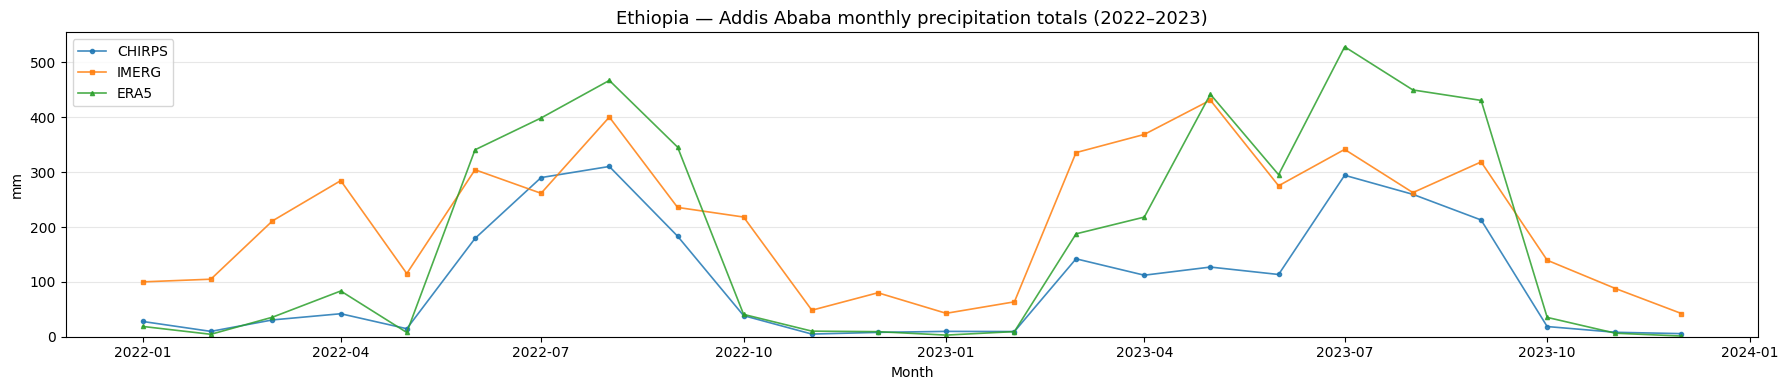

  💾 Saved: ./Results_SkillExplorer_Ethiopia_2026-06-28/ltn_monthly_Ethiopia.png


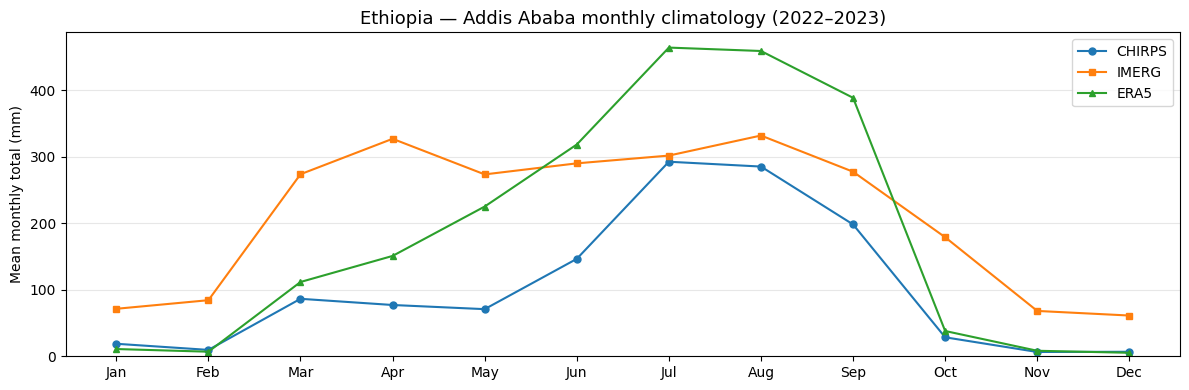

  💾 Saved: ./Results_SkillExplorer_Ethiopia_2026-06-28/ltn_climatology_Ethiopia.png


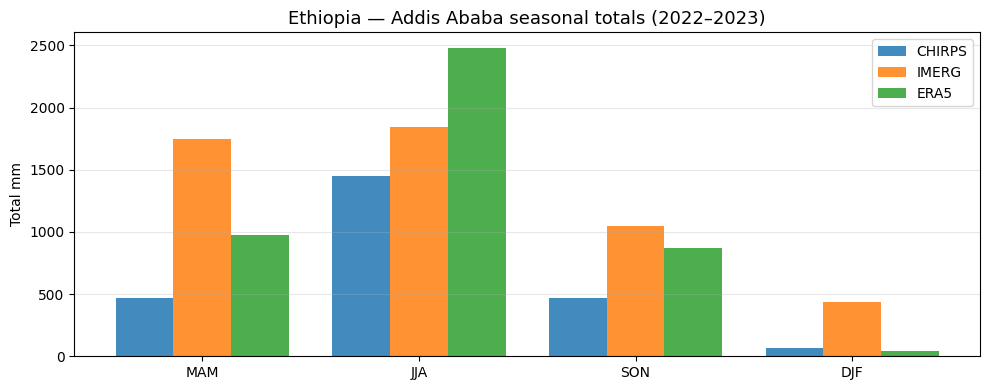

  💾 Saved: ./Results_SkillExplorer_Ethiopia_2026-06-28/ltn_seasonal_Ethiopia.png


,dataset,slope,p,direction
0,CHIRPS,0.039836,0.940682,no_significant_trend
1,IMERG,0.975676,0.901298,no_significant_trend
2,ERA5,1.324131,0.568338,no_significant_trend



  Trend summary:
  CHIRPS   slope=+0.04 mm/month  p=0.941  → no_significant_trend
  IMERG    slope=+0.98 mm/month  p=0.901  → no_significant_trend
  ERA5     slope=+1.32 mm/month  p=0.568  → no_significant_trend

✅ Step 4 complete — 3 datasets, 3 plots + trend table saved to ./Results_SkillExplorer_Ethiopia_2026-06-28


In [5]:
# @title Step 4: Long-term precipitation trends and climatology {"display-mode":"form"}
# Modified for Ethiopia, Tanzania, Eritrea, Djibouti
# Runs satellite-only, skips any dataset that failed to load

import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os

cap = CAPITALS[COUNTRY]

# ── Dataset registry — uses variable names from Steps 1 & 3 ──────────────────
# Maps display name → in-memory dataset variable
_ds_registry = {
    'CHIRPS': chirps_ds,
    'TAMSAT': tamsat_ds,
    'ERA5':   era5_ds,
    'IMERG':  imerg_ds,
}

# ── Extract pentad timeseries at capital, filter to configured date range ─────
series = {}
for name in Satellite_data_options:
    ds = _ds_registry.get(name)
    if ds is None:
        print(f'  ⚠️  {name}: not loaded — skipping')
        continue

    ts = extract_timeseries(ds, cap['lat'], cap['lon'], k=NEIGHBORHOOD)
    if ts is None or ts.empty:
        print(f'  ⚠️  {name}: no data at capital ({cap["lat"]}, {cap["lon"]}) — skipping')
        continue

    # Filter to configured date range (handles stale cached files)
    ts = ts[
        (ts.index >= pd.to_datetime(START_DATE)) &
        (ts.index <= pd.to_datetime(END_DATE))
    ]
    if ts.empty:
        print(f'  ⚠️  {name}: no data within {START_DATE} → {END_DATE} — skipping')
        continue

    ms = pentad_to_monthly(ts)
    if ms is not None and not ms.empty:
        series[name] = ms
        print(f'  ✅ {name}: {len(ms)} monthly values '
              f'({ms.index[0].date()} → {ms.index[-1].date()})')

if not series:
    print('ℹ️  No satellite series available — check NetCDFs loaded in Step 1.')
else:
    markers    = ['o', 's', '^', 'D']
    colors     = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    date_label = f'{START_DATE[:4]}–{END_DATE[:4]}'

    # ── Plot 1: Monthly totals time series ────────────────────────────────────
    fig, ax = plt.subplots(figsize=(18, 4))
    for i, (name, ms) in enumerate(series.items()):
        ax.plot(ms.index, ms.values,
                label=name,
                marker=markers[i % len(markers)],
                color=colors[i % len(colors)],
                linewidth=1.2, markersize=3, alpha=0.85)

    ax.set_title(f'{COUNTRY} — {cap["name"]} monthly precipitation totals '
                 f'({date_label})', fontsize=13)
    ax.set_ylabel('mm')
    ax.set_xlabel('Month')
    ax.set_ylim(bottom=0)
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    out = os.path.join(RESULTS_DIR, f'ltn_monthly_{COUNTRY}.png')
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'  💾 Saved: {out}')

    # ── Plot 2: Monthly climatology ───────────────────────────────────────────
    clims = {name: ms.groupby(ms.index.month).mean() for name, ms in series.items()}

    fig, ax = plt.subplots(figsize=(12, 4))
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']
    for i, (name, cl) in enumerate(clims.items()):
        ax.plot(range(1, 13), cl.reindex(range(1, 13)).values,
                marker=markers[i % len(markers)],
                color=colors[i % len(colors)],
                label=name, linewidth=1.5, markersize=5)

    ax.set_title(f'{COUNTRY} — {cap["name"]} monthly climatology ({date_label})',
                 fontsize=13)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_ylabel('Mean monthly total (mm)')
    ax.set_ylim(bottom=0)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    out = os.path.join(RESULTS_DIR, f'ltn_climatology_{COUNTRY}.png')
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'  💾 Saved: {out}')

    # ── Plot 3: Seasonal totals (MAM / JJA / SON / DJF) ──────────────────────
    # Important for East Africa: Ethiopia = MAM + OND; Tanzania = OND dominant
    SEASONS = {'MAM': [3,4,5], 'JJA': [6,7,8], 'SON': [9,10,11], 'DJF': [12,1,2]}
    seasonal_rows = []
    for name, ms in series.items():
        for season, months in SEASONS.items():
            total = ms[ms.index.month.isin(months)].sum()
            seasonal_rows.append({'dataset': name, 'season': season, 'total_mm': round(total, 1)})

    df_seasonal = pd.DataFrame(seasonal_rows)
    pivot       = df_seasonal.pivot(index='season', columns='dataset', values='total_mm')
    pivot       = pivot.reindex(['MAM', 'JJA', 'SON', 'DJF'])

    fig, ax = plt.subplots(figsize=(10, 4))
    x     = np.arange(len(pivot))
    width = 0.8 / max(len(series), 1)
    for i, name in enumerate(series.keys()):
        if name in pivot.columns:
            ax.bar(x + i * width, pivot[name],
                   width=width, label=name,
                   color=colors[i % len(colors)], alpha=0.85)

    ax.set_title(f'{COUNTRY} — {cap["name"]} seasonal totals ({date_label})',
                 fontsize=13)
    ax.set_xticks(x + width * (len(series) - 1) / 2)
    ax.set_xticklabels(pivot.index)
    ax.set_ylabel('Total mm')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    out = os.path.join(RESULTS_DIR, f'ltn_seasonal_{COUNTRY}.png')
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'  💾 Saved: {out}')

    # ── Mann-Kendall trend table ──────────────────────────────────────────────
    rows = [{'dataset': name, **mann_kendall(ms)} for name, ms in series.items()]
    df_trends = pd.DataFrame(rows)
    display(df_trends)
    df_trends.to_csv(os.path.join(RESULTS_DIR, f'ltn_trends_{COUNTRY}.csv'), index=False)

    print(f'\n  Trend summary:')
    for _, r in df_trends.iterrows():
        print(f'  {r["dataset"]:<8} slope={r["slope"]:+.2f} mm/month  '
              f'p={r["p"]:.3f}  → {r["direction"]}')

    print(f'\n✅ Step 4 complete — {len(series)} datasets, '
          f'3 plots + trend table saved to {RESULTS_DIR}')

ℹ️  No ground data for Ethiopia — extracting satellite pentads at capital.
   Capital: Addis Ababa (9.032, 38.7469)

  ✅ CHIRPS: 144 pentads | range 0.6–103.8 mm
  ⚠️  TAMSAT: not loaded — skipping
  ✅ IMERG: 146 pentads | range 1.9–173.4 mm
  ✅ ERA5: 146 pentads | range 0.0–172.1 mm

  💾 Satellite pentad table saved: ./Results_SkillExplorer_Ethiopia_2026-06-28/satellite_pentads_capital_Ethiopia.csv


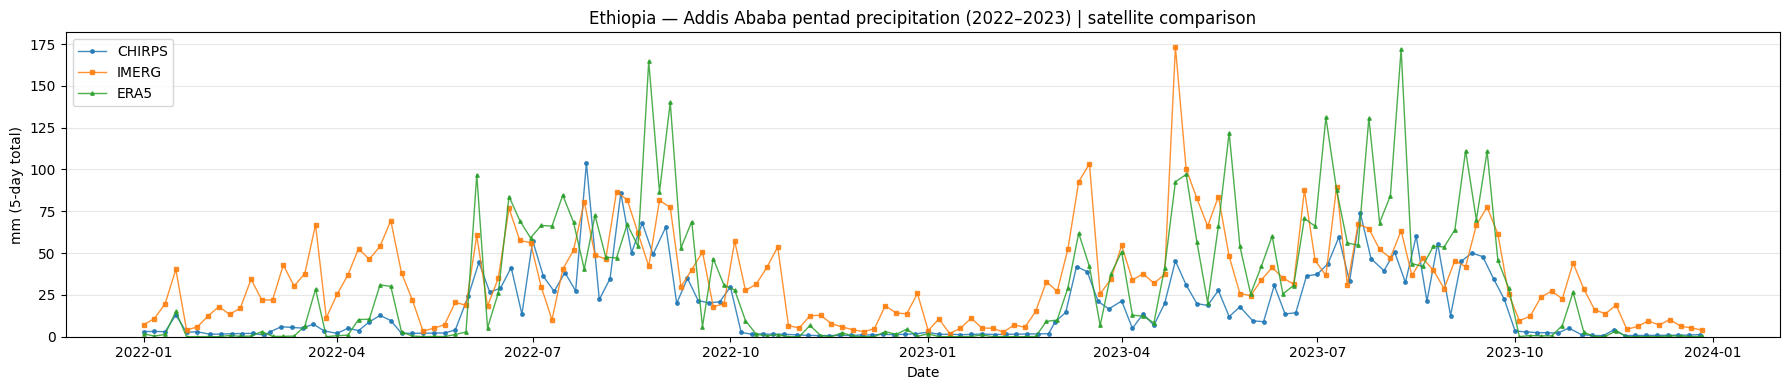

  💾 Saved: ./Results_SkillExplorer_Ethiopia_2026-06-28/satellite_pentads_capital_Ethiopia.png

  Inter-product Pearson correlation at Addis Ababa:


,CHIRPS,IMERG,ERA5
CHIRPS,1.000,0.898,0.819
IMERG,0.898,1.000,0.650
ERA5,0.819,0.650,1.000


  💾 Saved: ./Results_SkillExplorer_Ethiopia_2026-06-28/interproduct_corr_Ethiopia.csv

────────────────────────────────────────────────────────────
  Step 5 complete — Ethiopia
  Ground pentads : ⚠️  not available
  Steps 6-7      : will skip (no ground truth)
────────────────────────────────────────────────────────────


In [8]:
# @title Step 5: Aggregation to pentads {"display-mode":"form"}
# @markdown Aggregates ground truth to pentads when available.
# @markdown In satellite-only mode, extracts pentad series at the capital for all loaded products.

import matplotlib.pyplot as plt, os, pandas as pd, numpy as np

# Ensure the local results directory exists before saving anything
os.makedirs(RESULTS_DIR, exist_ok=True)

cap = CAPITALS[COUNTRY]

# ─────────────────────────────────────────────────────────────────────────────
# PATH A: Ground data available — aggregate stations to pentads
# ─────────────────────────────────────────────────────────────────────────────
if df_gt is not None and not df_gt.empty:

    # ── Station filter ────────────────────────────────────────────────────────
    if (High_confidence_stations and
            High_confidence_stations != 'auto' and
            High_confidence_stations != ['none']):
        available = [s for s in High_confidence_stations
                     if s in df_gt['station_id'].unique()]
        if available:
            df_gt_filtered = df_gt[df_gt['station_id'].isin(available)].copy()
            print(f'  Filtering to {len(available)} high-confidence stations: {available}')
        else:
            print('  ⚠️  Specified high-confidence stations not found — using all stations.')
            df_gt_filtered = df_gt.copy()
    else:
        print(f'  Using all stations (high_confidence_stations = {High_confidence_stations})')
        df_gt_filtered = df_gt.copy()

    # ── Date filter ───────────────────────────────────────────────────────────
    start_utc = pd.to_datetime(START_DATE, utc=True)
    end_utc   = pd.to_datetime(END_DATE,   utc=True)
    if df_gt_filtered['date'].dt.tz is None:
        df_gt_filtered['date'] = df_gt_filtered['date'].dt.tz_localize('UTC')
    df_gt_filtered = df_gt_filtered[
        (df_gt_filtered['date'] >= start_utc) &
        (df_gt_filtered['date'] <= end_utc)
    ].copy()

    # ── Pivot wide and resample to 5-day sums ────────────────────────────────
    ground_truth_pentad = (
        df_gt_filtered
        .pivot_table(index='date', columns='station_id', values='precip')
        .resample('5D').sum(min_count=1)
    )

    if ground_truth_pentad.empty:
        print('⚠️  Pentad DataFrame is empty after aggregation.')
        ground_truth_pentads_df = None
    else:
        ground_truth_pentads_df = ground_truth_pentad
        out = os.path.join(RESULTS_DIR, f'ground_truth_pentads_{COUNTRY}.csv')
        ground_truth_pentad.to_csv(out)

        print(f'✅ Ground truth pentads: {ground_truth_pentad.shape[0]} pentads × '
              f'{ground_truth_pentad.shape[1]} stations')
        print(f'   Date range : {ground_truth_pentad.index[0].date()} → '
              f'{ground_truth_pentad.index[-1].date()}')
        print(f'   Saved      : {out}')
        display(ground_truth_pentads_df.head())

        # ── Quick completeness plot ───────────────────────────────────────────
        completeness = ground_truth_pentad.notna().mean() * 100
        fig, ax = plt.subplots(figsize=(max(6, len(completeness) * 0.6), 4))
        bars = ax.bar(completeness.index, completeness.values,
                      color='steelblue', alpha=0.85)
        ax.axhline(80, color='red', linestyle='--', linewidth=0.8,
                   label='80% threshold')
        ax.set_title(f'{COUNTRY} — station data completeness ({START_DATE[:4]}–{END_DATE[:4]})')
        ax.set_ylabel('% pentads with data')
        ax.set_ylim(0, 105)
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
        plt.tight_layout()
        comp_out = os.path.join(RESULTS_DIR, f'station_completeness_{COUNTRY}.png')
        plt.savefig(comp_out, dpi=150)
        plt.show()
        print(f'  💾 Saved: {comp_out}')

# ─────────────────────────────────────────────────────────────────────────────
# PATH B: No ground data — extract satellite pentad series at capital city
# This keeps Steps 6-7 from crashing by setting ground_truth_pentads_df = None
# and producing a satellite comparison table instead
# ─────────────────────────────────────────────────────────────────────────────
else:
    print(f'ℹ️  No ground data for {COUNTRY} — extracting satellite pentads at capital.')
    print(f'   Capital: {cap["name"]} ({cap["lat"]}, {cap["lon"]})\n')

    ground_truth_pentads_df = None   # Steps 6-7 will check this and skip scoring

    _ds_registry = {
        'CHIRPS': chirps_ds,
        'TAMSAT': tamsat_ds,
        'ERA5':   era5_ds,
        'IMERG':  imerg_ds,
    }

    sat_pentads = {}
    for name in Satellite_data_options:
        ds = _ds_registry.get(name)
        if ds is None:
            print(f'  ⚠️  {name}: not loaded — skipping')
            continue
        ts = extract_timeseries(ds, cap['lat'], cap['lon'], k=NEIGHBORHOOD)
        if ts is None or ts.empty:
            print(f'  ⚠️  {name}: no data extracted at capital — skipping')
            continue
        ts = ts[
            (ts.index >= pd.to_datetime(START_DATE)) &
            (ts.index <= pd.to_datetime(END_DATE))
        ]
        if not ts.empty:
            sat_pentads[name] = ts
            print(f'  ✅ {name}: {len(ts)} pentads | '
                  f'range {ts.min():.1f}–{ts.max():.1f} mm')

    if sat_pentads:
        # Save satellite pentads at capital to CSV
        sat_df  = pd.DataFrame(sat_pentads)
        sat_out = os.path.join(RESULTS_DIR,
                               f'satellite_pentads_capital_{COUNTRY}.csv')
        sat_df.to_csv(sat_out)
        print(f'\n  💾 Satellite pentad table saved: {sat_out}')

        # ── Plot: satellite pentad comparison at capital ──────────────────────
        markers = ['o', 's', '^', 'D']
        colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

        fig, ax = plt.subplots(figsize=(18, 4))
        for i, (name, ts) in enumerate(sat_pentads.items()):
            ax.plot(ts.index, ts.values,
                    label=name,
                    marker=markers[i % len(markers)],
                    color=colors[i % len(colors)],
                    linewidth=1.0, markersize=2.5, alpha=0.85)

        ax.set_title(f'{COUNTRY} — {cap["name"]} pentad precipitation '
                     f'({START_DATE[:4]}–{END_DATE[:4]}) | satellite comparison',
                     fontsize=12)
        ax.set_ylabel('mm (5-day total)')
        ax.set_xlabel('Date')
        ax.set_ylim(bottom=0)
        ax.legend(loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plot_out = os.path.join(RESULTS_DIR,
                                f'satellite_pentads_capital_{COUNTRY}.png')
        plt.savefig(plot_out, dpi=150)
        plt.show()
        print(f'  💾 Saved: {plot_out}')

        # ── Inter-product correlation table ───────────────────────────────────
        if len(sat_pentads) > 1:
            corr_df = sat_df.corr(method='pearson').round(3)
            print(f'\n  Inter-product Pearson correlation at {cap["name"]}:')
            display(corr_df)
            corr_out = os.path.join(RESULTS_DIR,
                                    f'interproduct_corr_{COUNTRY}.csv')
            corr_df.to_csv(corr_out)
            print(f'  💾 Saved: {corr_out}')
    else:
        print('  ❌ No satellite data extracted. Check datasets loaded in Step 1.')

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY FLAG for downstream steps
# ─────────────────────────────────────────────────────────────────────────────
ground_pentads_available = (
    ground_truth_pentads_df is not None and
    not ground_truth_pentads_df.empty
)

print(f'\n{"─"*60}')
print(f'  Step 5 complete — {COUNTRY}')
print(f'  Ground pentads : {"✅ available" if ground_pentads_available else "⚠️  not available"}')
print(f'  Steps 6-7      : {"will run station scoring" if ground_pentads_available else "will skip (no ground truth)"}')
print(f'{"─"*60}')

ℹ️  No ground data for Ethiopia — comparing satellite products at Addis Ababa (9.032, 38.7469)

  ✅ CHIRPS: 144 pentads | 0.6–103.8 mm
  ⚠️  TAMSAT: not loaded — skipping
  ✅ IMERG: 146 pentads | 1.9–173.4 mm
  ✅ ERA5: 146 pentads | 0.0–172.1 mm


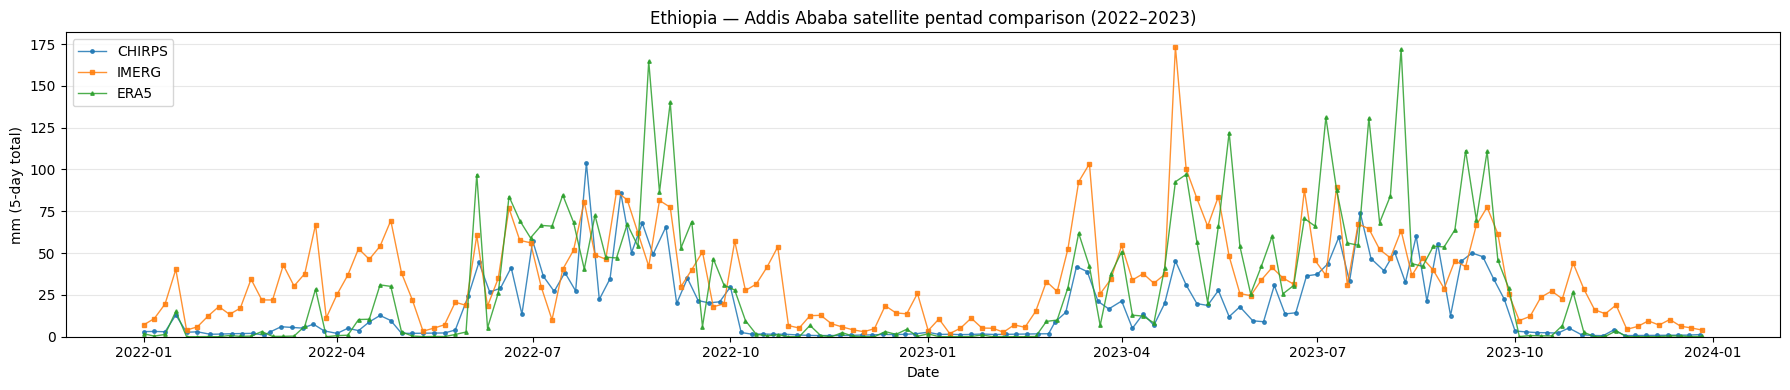

  💾 Saved: ./Results_SkillExplorer_Ethiopia_2026-06-28/satellite_comparison_Ethiopia.png


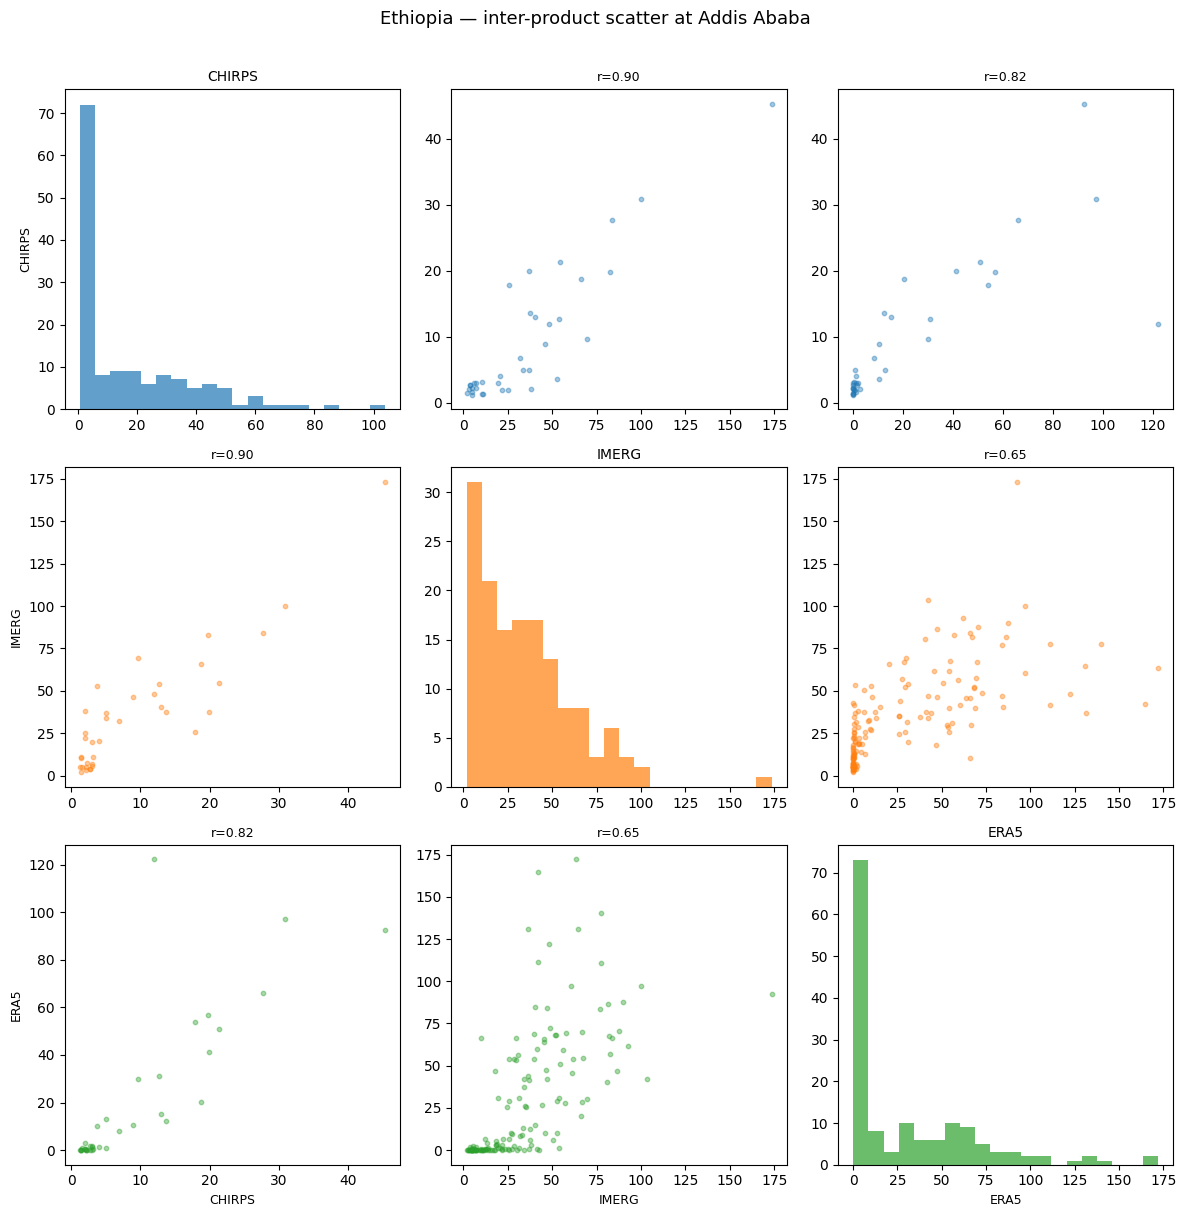

  💾 Saved: ./Results_SkillExplorer_Ethiopia_2026-06-28/interproduct_scatter_Ethiopia.png

  Pearson correlation at Addis Ababa:


,CHIRPS,IMERG,ERA5
CHIRPS,1.000,0.898,0.819
IMERG,0.898,1.000,0.650
ERA5,0.819,0.650,1.000



────────────────────────────────────────────────────────────
  Step 6 complete — Ethiopia
  Mode              : satellite-only at Addis Ababa
  Products compared : ['CHIRPS', 'IMERG', 'ERA5']
────────────────────────────────────────────────────────────


In [9]:
# @title Step 6: Build nearest satellite data for stations {"display-mode":"form"}
# @markdown Extracts satellite values at station locations (ground mode)
# @markdown or compares products at the capital city (satellite-only mode)

import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
import ipywidgets as W
from IPython.display import display, clear_output

# Ensure the local results directory exists before saving anything
os.makedirs(RESULTS_DIR, exist_ok=True)

cap = CAPITALS[COUNTRY]

# ── Dataset registry ──────────────────────────────────────────────────────────
_ds_registry = {
    'CHIRPS': chirps_ds,
    'TAMSAT': tamsat_ds,
    'ERA5':   era5_ds,
    'IMERG':  imerg_ds,
}

# ─────────────────────────────────────────────────────────────────────────────
# CORE FUNCTION: sample any grid dataset at a point or k×k neighbourhood
# Works with lat/lon (from _tiffs_to_nc) and y/x (original TAHMO shared files)
# ─────────────────────────────────────────────────────────────────────────────
def build_station_dataset_from_grid(grid_ds, stations_metadata, k=NEIGHBORHOOD):
    """
    Sample grid values at station locations.
    stations_metadata must have columns: code/station_id, lat, lon
    Returns a DataFrame with station codes as columns and time as index.
    """
    if grid_ds is None:
        return None

    # ── Detect spatial coordinate names ──────────────────────────────────────
    if 'lat' in grid_ds.coords and 'lon' in grid_ds.coords:
        grid_lats, grid_lons = grid_ds['lat'].values, grid_ds['lon'].values
        lat_dim, lon_dim     = 'lat', 'lon'
    elif 'y' in grid_ds.coords and 'x' in grid_ds.coords:
        grid_lats, grid_lons = grid_ds['y'].values, grid_ds['x'].values
        lat_dim, lon_dim     = 'y', 'x'
    elif 'latitude' in grid_ds.coords and 'longitude' in grid_ds.coords:
        grid_lats, grid_lons = grid_ds['latitude'].values, grid_ds['longitude'].values
        lat_dim, lon_dim     = 'latitude', 'longitude'
    else:
        print(f'⚠️  No spatial coords found. Available: {list(grid_ds.coords)}')
        return None

    # ── Detect precipitation variable ─────────────────────────────────────────
    precip_var = next(
        (v for v in grid_ds.data_vars
         if any(k in v.lower() for k in ['precip', 'rainfall', 'precipitation',
                                          'rfe', 'cal', 'total_precip'])
         and lat_dim in grid_ds[v].dims
         and 'time'  in grid_ds[v].dims),
        list(grid_ds.data_vars)[0] if grid_ds.data_vars else None
    )
    if precip_var is None:
        print('⚠️  No precipitation variable found in dataset.')
        return None

    # ── Detect station ID and coordinate columns ───────────────────────────────
    id_col  = next((c for c in stations_metadata.columns
                    if c.lower() in ['code', 'station_id', 'id', 'stationid']), None)
    lat_col = next((c for c in stations_metadata.columns if 'lat' in c.lower()), None)
    lon_col = next((c for c in stations_metadata.columns
                    if 'lon' in c.lower() or 'lng' in c.lower()), None)

    if not all([id_col, lat_col, lon_col]):
        print(f'⚠️  Cannot find id/lat/lon in metadata. '
              f'Columns: {list(stations_metadata.columns)}')
        return None

    all_stations = {}
    for _, row in stations_metadata.iterrows():
        sid = row[id_col]
        lat = float(row[lat_col])
        lon = float(row[lon_col])

        lat_idx = int(np.abs(grid_lats - lat).argmin())
        lon_idx = int(np.abs(grid_lons - lon).argmin())

        if k == 1:
            sub = grid_ds[precip_var].isel({lat_dim: lat_idx, lon_dim: lon_idx})
        else:
            sub = grid_ds[precip_var].isel({
                lat_dim: slice(max(lat_idx - k // 2, 0),
                               min(lat_idx + k // 2 + 1, len(grid_lats))),
                lon_dim: slice(max(lon_idx - k // 2, 0),
                               min(lon_idx + k // 2 + 1, len(grid_lons)))
            })
            if sub[lat_dim].size == 0 or sub[lon_dim].size == 0:
                print(f'  ⚠️  {sid}: near grid edge, skipping neighbourhood average.')
                sub = grid_ds[precip_var].isel({lat_dim: lat_idx, lon_dim: lon_idx})
            else:
                sub = sub.mean(dim=[lat_dim, lon_dim], skipna=True)

        try:
            s = sub.to_series()
            s.name = sid
            all_stations[sid] = s
        except Exception as e:
            print(f'  ⚠️  {sid}: conversion error — {e}')
            all_stations[sid] = pd.Series(dtype=float)

    if not all_stations:
        return None

    return pd.concat(all_stations.values(), axis=1, keys=all_stations.keys())


# ─────────────────────────────────────────────────────────────────────────────
# PATH A: Ground data available — extract satellite values at station locations
# ─────────────────────────────────────────────────────────────────────────────
station_datasets        = {}
pentad_station_datasets = {}

if ground_pentads_available and df_gt is not None and not df_gt.empty:
    print(f'✅ Ground data available — extracting satellite values at stations\n')

    # ── Load or reuse station metadata ────────────────────────────────────────
    metadata_csv = './tahmo_metadata.csv'
    if 'df_meta' not in locals() or (hasattr(df_meta, 'empty') and df_meta.empty):
        if os.path.exists(metadata_csv):
            df_meta = pd.read_csv(metadata_csv)
            print(f'  Loaded metadata: {len(df_meta)} stations')
        else:
            # Build minimal metadata from df_gt itself
            print(f'  ℹ️  No metadata CSV — building from df_gt coordinates')
            df_meta = (df_gt.groupby('station_id')
                            .agg(lat=('lat', 'first'), lon=('lon', 'first'))
                            .reset_index()
                            .rename(columns={'station_id': 'code'}))

    # ── Select stations ───────────────────────────────────────────────────────
    all_station_ids = df_gt['station_id'].unique().tolist()

    if (High_confidence_stations and
            High_confidence_stations != 'auto' and
            High_confidence_stations != ['none']):
        selected = [s for s in High_confidence_stations if s in all_station_ids]
        if not selected:
            print('  ⚠️  Specified high-confidence stations not in ground data — using all')
            selected = all_station_ids
        else:
            print(f'  Using {len(selected)} high-confidence stations: {selected}')
    else:
        selected = all_station_ids
        print(f'  Using all {len(selected)} stations (auto mode)')

    # Filter metadata to selected stations
    id_col = next((c for c in df_meta.columns
                   if c.lower() in ['code', 'station_id', 'id']), None)
    if id_col:
        stations_meta_filtered = df_meta[df_meta[id_col].isin(selected)].copy()
    else:
        stations_meta_filtered = df_meta.copy()

    if stations_meta_filtered.empty:
        print('  ⚠️  No matching station metadata — cannot extract satellite values.')
    else:
        # ── Extract per-dataset ───────────────────────────────────────────────
        for name in Satellite_data_options:
            ds = _ds_registry.get(name)
            if ds is None:
                print(f'  ⚠️  {name}: not loaded — skipping')
                continue
            print(f'  Extracting {name}...')
            df_sat = build_station_dataset_from_grid(
                ds, stations_meta_filtered, k=NEIGHBORHOOD)
            if df_sat is not None and not df_sat.empty:
                station_datasets[name] = df_sat
                print(f'  ✅ {name}: {df_sat.shape[1]} stations × '
                      f'{df_sat.shape[0]} timesteps')
            else:
                print(f'  ⚠️  {name}: no data extracted')

        # ── Aggregate to pentads ──────────────────────────────────────────────
        origin_dt = pd.to_datetime(START_DATE, utc=True)
        for name, daily_df in station_datasets.items():
            if daily_df is None or daily_df.empty:
                continue
            if daily_df.index.tzinfo is None:
                daily_df = daily_df.tz_localize('UTC')
            pentad_df = daily_df.resample('5D', origin=origin_dt).sum(min_count=1)
            pentad_station_datasets[name] = pentad_df
            print(f'  ✅ {name} → pentads: {pentad_df.shape}')

    # ── Interactive station plot ──────────────────────────────────────────────
    stations_to_plot = selected if selected else all_station_ids

    if stations_to_plot:
        station_w = W.Dropdown(
            options=stations_to_plot,
            description='Station:',
        )
        toggle_w = W.ToggleButtons(
            options=['Show Plot', 'Hide Plot'],
            description='Time series:',
        )
        display(W.VBox([station_w, toggle_w]))

        def update_plot(change):
            clear_output(wait=True)
            display(W.VBox([station_w, toggle_w]))
            if toggle_w.value != 'Show Plot':
                return

            sid = station_w.value
            st  = df_gt[df_gt['station_id'] == sid].sort_values('date').copy()
            if st.empty:
                print(f'⚠️  No ground data for {sid}')
                return

            st_idx = st.set_index('date')['precip']
            if st_idx.index.tzinfo is None:
                st_idx.index = st_idx.index.tz_localize('UTC')
            ground_pentad = st_idx.resample(
                '5D', origin=pd.to_datetime(START_DATE, utc=True)
            ).sum(min_count=1)

            markers = ['o', 's', '^', 'D', 'x']
            colors  = ['black', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

            fig, ax = plt.subplots(figsize=(18, 4))
            ax.plot(ground_pentad.index, ground_pentad.values,
                    label='Ground', color='black', marker='o',
                    linewidth=1.2, markersize=3)

            for i, name in enumerate(Satellite_data_options):
                pds = pentad_station_datasets.get(name)
                if pds is not None and sid in pds.columns:
                    s = pds[sid]
                    if s.index.tzinfo is None:
                        s.index = s.index.tz_localize('UTC')
                    aligned = s.reindex(ground_pentad.index, method='nearest',
                                        tolerance=pd.Timedelta('3D'))
                    ax.plot(aligned.index, aligned.values,
                            label=name,
                            color=colors[(i + 1) % len(colors)],
                            marker=markers[(i + 1) % len(markers)],
                            linewidth=1.0, markersize=2.5, alpha=0.85)

            ax.set_title(f'{COUNTRY} — Station {sid} pentad precipitation '
                         f'({START_DATE[:4]}–{END_DATE[:4]})')
            ax.set_ylabel('mm (5-day)')
            ax.set_xlabel('Date')
            ax.set_ylim(bottom=0)
            ax.legend(loc='upper left')
            ax.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            out = os.path.join(RESULTS_DIR, f'station_pentad_{sid}_{COUNTRY}.png')
            plt.savefig(out, dpi=150)
            display(fig)
            plt.close(fig)

        station_w.observe(update_plot, names='value')
        toggle_w.observe(update_plot, names='value')
        update_plot(None)

# ─────────────────────────────────────────────────────────────────────────────
# PATH B: No ground data — compare satellite products at capital city
# ─────────────────────────────────────────────────────────────────────────────
else:
    print(f'ℹ️  No ground data for {COUNTRY} — comparing satellite products '
          f'at {cap["name"]} ({cap["lat"]}, {cap["lon"]})\n')

    sat_series = {}
    for name in Satellite_data_options:
        ds = _ds_registry.get(name)
        if ds is None:
            print(f'  ⚠️  {name}: not loaded — skipping')
            continue
        ts = extract_timeseries(ds, cap['lat'], cap['lon'], k=NEIGHBORHOOD)
        if ts is None or ts.empty:
            print(f'  ⚠️  {name}: no data at capital — skipping')
            continue
        ts = ts[
            (ts.index >= pd.to_datetime(START_DATE)) &
            (ts.index <= pd.to_datetime(END_DATE))
        ]
        if not ts.empty:
            sat_series[name] = ts
            print(f'  ✅ {name}: {len(ts)} pentads | '
                  f'{ts.min():.1f}–{ts.max():.1f} mm')

    if not sat_series:
        print('  ❌ No satellite data available. Check Step 1.')
    else:
        markers = ['o', 's', '^', 'D']
        colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

        # ── Time series comparison plot ───────────────────────────────────────
        fig, ax = plt.subplots(figsize=(18, 4))
        for i, (name, ts) in enumerate(sat_series.items()):
            ax.plot(ts.index, ts.values,
                    label=name,
                    color=colors[i % len(colors)],
                    marker=markers[i % len(markers)],
                    linewidth=1.0, markersize=2.5, alpha=0.85)

        ax.set_title(f'{COUNTRY} — {cap["name"]} satellite pentad comparison '
                     f'({START_DATE[:4]}–{END_DATE[:4]})', fontsize=12)
        ax.set_ylabel('mm (5-day total)')
        ax.set_xlabel('Date')
        ax.set_ylim(bottom=0)
        ax.legend(loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        out = os.path.join(RESULTS_DIR, f'satellite_comparison_{COUNTRY}.png')
        plt.savefig(out, dpi=150)
        plt.show()
        print(f'  💾 Saved: {out}')

        # ── Scatter matrix: each product pair ────────────────────────────────
        names = list(sat_series.keys())
        if len(names) > 1:
            sat_df = pd.DataFrame(sat_series)
            n      = len(names)
            fig, axes = plt.subplots(n, n, figsize=(4 * n, 4 * n))
            for r, n1 in enumerate(names):
                for c, n2 in enumerate(names):
                    ax = axes[r][c] if n > 1 else axes
                    if r == c:
                        ax.hist(sat_df[n1].dropna(), bins=20,
                                color=colors[r % len(colors)], alpha=0.7)
                        ax.set_title(n1, fontsize=10)
                    else:
                        common = sat_df[[n1, n2]].dropna()
                        ax.scatter(common[n2], common[n1],
                                   alpha=0.4, s=10,
                                   color=colors[r % len(colors)])
                        if not common.empty:
                            r_val = common.corr().iloc[0, 1]
                            ax.set_title(f'r={r_val:.2f}', fontsize=9)
                    if c == 0:
                        ax.set_ylabel(n1, fontsize=9)
                    if r == n - 1:
                        ax.set_xlabel(n2, fontsize=9)

            fig.suptitle(f'{COUNTRY} — inter-product scatter '
                         f'at {cap["name"]}', fontsize=13, y=1.01)
            plt.tight_layout()
            out = os.path.join(RESULTS_DIR,
                               f'interproduct_scatter_{COUNTRY}.png')
            plt.savefig(out, dpi=150, bbox_inches='tight')
            plt.show()
            print(f'  💾 Saved: {out}')

            # ── Correlation table ─────────────────────────────────────────────
            corr = sat_df.corr(method='pearson').round(3)
            print(f'\n  Pearson correlation at {cap["name"]}:')
            display(corr)
            corr.to_csv(os.path.join(RESULTS_DIR,
                                      f'interproduct_corr_{COUNTRY}.csv'))

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print(f'\n{"─"*60}')
print(f'  Step 6 complete — {COUNTRY}')
if ground_pentads_available:
    print(f'  Station datasets  : {list(station_datasets.keys())}')
    print(f'  Pentad datasets   : {list(pentad_station_datasets.keys())}')
else:
    print(f'  Mode              : satellite-only at {cap["name"]}')
    print(f'  Products compared : {list(sat_series.keys()) if sat_series else "none"}')
print(f'{"─"*60}')

In [10]:
# @title Step 7: Compute Confidence Scores {"display-mode":"form"}
# @markdown ### **Confidence Score Formula**
# @markdown For each station, the confidence score is computed as:
# @markdown
# @markdown $$
# @markdown \text{Confidence Score} = 100 \times \big(0.1 \cdot C \;+\; 0.5 \cdot r \;+\; 0.1 \cdot (1 - O) \;+\; 0.3 \cdot(1- b) \big)
# @markdown $$
# @markdown
# @markdown Where:
# @markdown - $C = 1 -$ (missing fraction of observations), i.e. **completeness**
# @markdown - $r =$ Spearman correlation coefficient between observed and CHIRPS pentads
# @markdown - $O =$ fraction of outliers (observed values < 0)
# @markdown - $b =$ Bias Significance - paired $t$-test between observed and simulated values (significant if $p < 0.05$)
# @markdown
# @markdown ---
# @markdown
# @markdown **Additional metrics per station:**
# @markdown
# @markdown - **RMSE**
# @markdown $$
# @markdown \text{RMSE} = \sqrt{\frac{1}{n} \sum (obs - sim)^2}
# @markdown $$
# @markdown
# @markdown - **Adjusted confidence score**
# @markdown $$
# @markdown \text{Adjusted Confidence Score} = \text{Confidence Score} - \text{RMSE}
# @markdown $$
# @markdown
# @markdown Computes station confidence scores (if ground data is available)
# @markdown or satellite dataset quality scores (if in satellite-only mode).
# @markdown Uses weights and settings defined in Step 1, and data structures from Steps 5 & 6.

import numpy as np
import pandas as pd
import os
from scipy.stats import pearsonr, spearmanr, ttest_rel
from IPython.display import display

# Ensure the local results directory exists before saving anything
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Weights from Step 1 ──────────────────────────────────────────────────────
w_complete = globals().get('w_complete', 0.10)
w_corr     = globals().get('w_corr',     0.50)
w_outlier  = globals().get('w_outlier',  0.10)
w_bias     = globals().get('w_bias',     0.30)
corr_method = globals().get('CORR_METHOD', 'spearman')

# ── Helper functions ─────────────────────────────────────────────────────────
def _rmse(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return float(np.sqrt(np.nanmean((a - b) ** 2)))

def _correlate(obs, sim, method='spearman'):
    try:
        o = pd.to_numeric(obs, errors='coerce').dropna()
        s = pd.to_numeric(sim, errors='coerce').dropna()
        common = o.index.intersection(s.index)
        o, s = o.loc[common], s.loc[common]
        if len(o) < 3: return np.nan
        if method == 'pearson': r, _ = pearsonr(o, s)
        else: r, _ = spearmanr(o, s)
        return float(r)
    except Exception:
        return np.nan

# ── PATH A: Ground Data Available ────────────────────────────────────────────
if ground_pentads_available and df_gt is not None and not df_gt.empty:
    print("✅ Ground data detected. Computing Station Confidence Scores...\n")

    # Rebuild ground pentad DataFrame from df_gt (using START_DATE from Step 1)
    origin_dt = pd.to_datetime(START_DATE, utc=True)
    gt = df_gt.copy()
    if gt['date'].dt.tz is None:
        gt['date'] = gt['date'].dt.tz_localize('UTC')
    else:
        gt['date'] = gt['date'].dt.tz_convert('UTC')

    ground_pentad = (
        gt.pivot_table(index='date', columns='station_id', values='precip')
          .resample('5D', origin=origin_dt)
          .sum(min_count=1)
    )

    print(f"Ground pentad matrix : {ground_pentad.shape[1]} stations × {ground_pentad.shape[0]} pentads")
    print(f"Satellite products   : {list(pentad_station_datasets.keys())}\n")
    print("─" * 60)

    all_scores_dict = {}
    station_scores = None

    for product_name in Satellite_data_options:
        sim_pentad = pentad_station_datasets.get(product_name)
        if sim_pentad is None or sim_pentad.empty:
            print(f"⚠️  {product_name}: no pentad data — skipping\n")
            continue

        if sim_pentad.index.tzinfo is None:
            sim_pentad = sim_pentad.tz_localize('UTC')
        else:
            sim_pentad = sim_pentad.tz_convert('UTC')

        print(f"📊 Scoring stations against {product_name} ...")

        stations = ground_pentad.columns.intersection(sim_pentad.columns)
        if stations.empty:
            print("  ⚠️  No common stations.\n")
            continue

        sim_aligned = sim_pentad.reindex(ground_pentad.index)
        rows = []

        for sid in stations:
            obs_raw = ground_pentad[sid]
            sim_raw = sim_aligned[sid]

            obs_nn = obs_raw.dropna()
            sim_nn = sim_raw.dropna()
            common = obs_nn.index.intersection(sim_nn.index)
            obs_c, sim_c = obs_nn.loc[common], sim_nn.loc[common]
            n_pairs = len(common)

            r = _correlate(obs_c, sim_c, corr_method) if n_pairs >= 3 else np.nan
            error = _rmse(obs_c.values, sim_c.values) if n_pairs >= 1 else np.nan

            if n_pairs >= 2:
                try:
                    _, p_val = ttest_rel(
                        pd.to_numeric(obs_c, errors='coerce').fillna(0),
                        pd.to_numeric(sim_c, errors='coerce').fillna(0)
                    )
                    bias_signif = 'Significant' if p_val < 0.05 else 'Not Significant'
                except Exception:
                    p_val, bias_signif = np.nan, 'Error'
            else:
                p_val, bias_signif = np.nan, 'Insufficient data'

            completeness = 1.0 - float(obs_raw.isna().mean())
            outlier_rate = float((obs_raw < 0).mean())

            r_safe = float(np.nan_to_num(r, nan=0.0))
            pval_safe = float(np.nan_to_num(p_val, nan=1.0))

            score = 100 * (
                w_complete * completeness +
                w_corr * r_safe +
                w_outlier * (1 - outlier_rate) +
                w_bias * (1 - pval_safe)
            )

            rows.append({
                'station_id': sid,
                'confidence_score': round(score, 2),
                f'{corr_method}_r': round(r, 3) if not np.isnan(r) else np.nan,
                'spearman_r': round(r, 3) if not np.isnan(r) else np.nan,
                'rmse': round(error, 2) if not np.isnan(error) else np.nan,
                'bias_signif': bias_signif,
                'completeness': round(completeness, 3),
                'outlier_rate': round(outlier_rate, 4),
                'p_value': round(p_val, 4) if not np.isnan(p_val) else np.nan,
                'n_pairs': n_pairs,
                'dataset': product_name
            })

        if rows:
            scores_df = pd.DataFrame(rows)
            scores_df['adjusted_confidence_score'] = (scores_df['confidence_score'] - scores_df['rmse']).round(2)

            high_thr = globals().get('High_confidence_threshold', 70)
            low_thr = globals().get('Low_confidence_threshold', 40)

            def _classify(v):
                if v >= high_thr: return 'High'
                if v >= low_thr: return 'Medium'
                return 'Low'

            scores_df['class'] = scores_df['confidence_score'].apply(_classify)
            scores_df = scores_df.sort_values('adjusted_confidence_score', ascending=False)

            all_scores_dict[product_name] = scores_df

            display_cols = ['station_id', 'confidence_score', 'adjusted_confidence_score',
                            'class', f'{corr_method}_r', 'rmse', 'completeness', 'outlier_rate', 'bias_signif', 'n_pairs']
            display_cols = [c for c in display_cols if c in scores_df.columns]
            display(scores_df[display_cols])

            out_csv = os.path.join(RESULTS_DIR, f'{product_name}_station_scores_{COUNTRY}.csv')
            scores_df.to_csv(out_csv, index=False)
            print(f"  💾 Saved: {out_csv}\n")

    if 'CHIRPS' in all_scores_dict:
        station_scores = all_scores_dict['CHIRPS']
    elif all_scores_dict:
        station_scores = list(all_scores_dict.values())[0]

    print("═" * 60)
    print(f"  Step 7 complete (Ground Truth Mode) — {COUNTRY}")
    if station_scores is not None:
        print(f"  Products scored : {list(all_scores_dict.keys())}")
        hi  = (station_scores['class'] == 'High').sum()
        med = (station_scores['class'] == 'Medium').sum()
        lo  = (station_scores['class'] == 'Low').sum()
        print(f"  Station classes : High={hi}  Medium={med}  Low={lo}")
    print("═" * 60)

# ── PATH B: Satellite-Only Mode ──────────────────────────────────────────────
else:
    print("⚠️  No ground data detected. Computing Satellite Dataset Quality Scores at Capital...\n")

    # Extract satellite pentads at capital city (from Step 6 or re-extract)
    cap = CAPITALS[COUNTRY]

    # Check if sat_series was already created in Step 6
    if 'sat_series' not in locals() or not sat_series:
        sat_series = {}
        _ds_registry = {
            'CHIRPS': chirps_ds, 'TAMSAT': tamsat_ds,
            'ERA5':   era5_ds,   'IMERG':  imerg_ds,
        }
        for name in Satellite_data_options:
            ds = _ds_registry.get(name)
            if ds is not None:
                ts = extract_timeseries(ds, cap['lat'], cap['lon'], k=NEIGHBORHOOD)
                if ts is not None and not ts.empty:
                    ts = ts[(ts.index >= pd.to_datetime(START_DATE)) & (ts.index <= pd.to_datetime(END_DATE))]
                    if not ts.empty:
                        sat_series[name] = ts

    if not sat_series:
        print("❌ No satellite data available at capital city. Cannot compute scores.")
    else:
        print(f"📊 Evaluating {len(sat_series)} satellite products at {cap['name']}...\n")

        rows = []
        for product_name, ts in sat_series.items():
            # Completeness
            completeness = 1.0 - float(ts.isna().mean())

            # Outlier rate (negative values or extreme > 99th percentile)
            q99 = ts.quantile(0.99)
            outlier_rate = float(((ts < 0) | (ts > q99)).mean())

            # Inter-product correlation (mean correlation with other products)
            r_vals = []
            for other_name, other_ts in sat_series.items():
                if other_name != product_name:
                    r = _correlate(ts, other_ts, 'spearman')
                    if not np.isnan(r):
                        r_vals.append(r)
            mean_r = np.mean(r_vals) if r_vals else 0.0

            # Bias significance (Not applicable without ground truth, set p_val to 1.0)
            p_val = 1.0
            bias_signif = 'N/A (No Ground Truth)'

            r_safe = float(np.nan_to_num(mean_r, nan=0.0))
            pval_safe = float(np.nan_to_num(p_val, nan=1.0))

            score = 100 * (
                w_complete * completeness +
                w_corr * r_safe +
                w_outlier * (1 - outlier_rate) +
                w_bias * (1 - pval_safe) # This will be 0
            )

            rows.append({
                'dataset': product_name,
                'confidence_score': round(score, 2),
                'spearman_r': round(mean_r, 3),
                'rmse': np.nan,
                'bias_signif': bias_signif,
                'completeness': round(completeness, 3),
                'outlier_rate': round(outlier_rate, 4),
                'p_value': np.nan,
                'n_pairs': len(ts.dropna())
            })

        scores_df = pd.DataFrame(rows)
        scores_df['adjusted_confidence_score'] = scores_df['confidence_score']

        high_thr = globals().get('High_confidence_threshold', 70)
        low_thr = globals().get('Low_confidence_threshold', 40)

        def _classify(v):
            if v >= high_thr: return 'High'
            if v >= low_thr: return 'Medium'
            return 'Low'

        scores_df['class'] = scores_df['confidence_score'].apply(_classify)
        scores_df = scores_df.sort_values('confidence_score', ascending=False)

        display_cols = ['dataset', 'confidence_score', 'class', 'spearman_r',
                        'completeness', 'outlier_rate', 'bias_signif', 'n_pairs']
        display_cols = [c for c in display_cols if c in scores_df.columns]
        display(scores_df[display_cols])

        out_csv = os.path.join(RESULTS_DIR, f'satellite_quality_scores_{COUNTRY}.csv')
        scores_df.to_csv(out_csv, index=False)
        print(f"  💾 Saved: {out_csv}\n")

        print("═" * 60)
        print(f"  Step 7 complete (Satellite-Only Mode) — {COUNTRY}")
        print(f"  Products evaluated: {list(sat_series.keys())}")
        print("═" * 60)

⚠️  No ground data detected. Computing Satellite Dataset Quality Scores at Capital...

📊 Evaluating 3 satellite products at Addis Ababa...



,dataset,confidence_score,class,spearman_r,completeness,outlier_rate,bias_signif,n_pairs
2,ERA5,61.90,Medium,0.841,1.0,0.0137,N/A (No Ground Truth),146
0,CHIRPS,61.83,Medium,0.839,1.0,0.0139,N/A (No Ground Truth),144
1,IMERG,60.38,Medium,0.810,1.0,0.0137,N/A (No Ground Truth),146


  💾 Saved: ./Results_SkillExplorer_Ethiopia_2026-06-28/satellite_quality_scores_Ethiopia.csv

════════════════════════════════════════════════════════════
  Step 7 complete (Satellite-Only Mode) — Ethiopia
  Products evaluated: ['CHIRPS', 'IMERG', 'ERA5']
════════════════════════════════════════════════════════════


✅ Satellite-Only Mode: Satellite Product Quality Scores at Capital City:


,dataset,confidence_score,spearman_r,rmse,bias_signif,completeness,outlier_rate,p_value,n_pairs,adjusted_confidence_score,class
2,ERA5,61.90,0.841,NaN,N/A (No Ground Truth),1.0,0.0137,NaN,146,61.90,Medium
0,CHIRPS,61.83,0.839,NaN,N/A (No Ground Truth),1.0,0.0139,NaN,144,61.83,Medium
1,IMERG,60.38,0.810,NaN,N/A (No Ground Truth),1.0,0.0137,NaN,146,60.38,Medium


💾 Satellite quality scores saved to ./Results_SkillExplorer_Ethiopia_2026-06-28/satellite_quality_scores_Ethiopia.csv

Generating visualizations...


/tmp/ipykernel_10041/1839780140.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


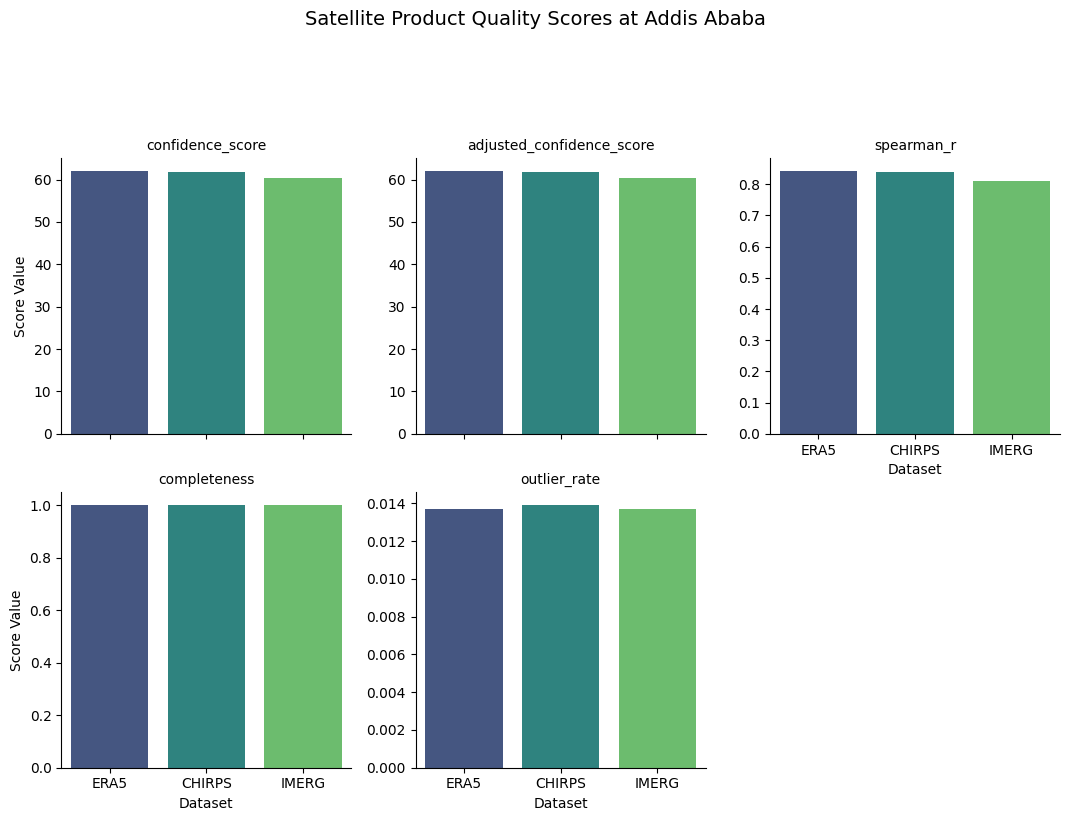

💾 Scores comparison plot saved to ./Results_SkillExplorer_Ethiopia_2026-06-28/scores_comparison_bar_Ethiopia.png



/tmp/ipykernel_10041/1839780140.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_scores_df, x='dataset', y='confidence_score', palette='Set2')


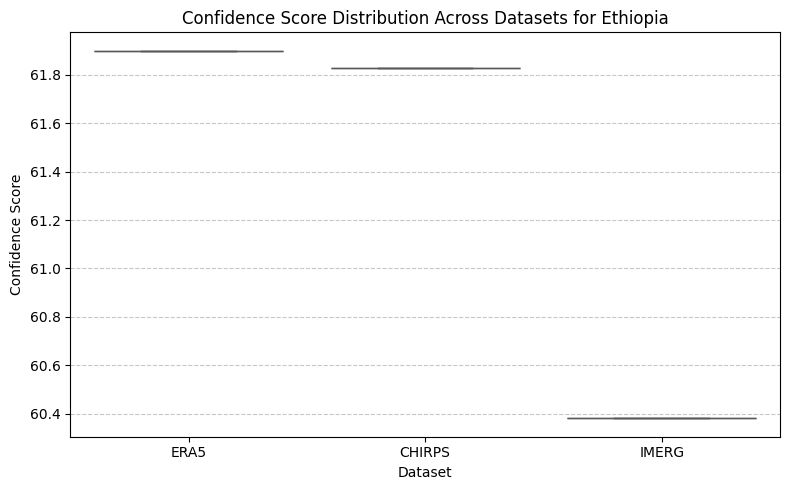

💾 Confidence score boxplot saved to ./Results_SkillExplorer_Ethiopia_2026-06-28/confidence_boxplot_Ethiopia.png


In [11]:
# @title Step 8: Visualize Station Scores Across Datasets {"display-mode":"form"}
# @markdown This step visualizes the computed station scores (confidence, RMSE, correlation, etc.)
# @markdown across the different satellite datasets.
# @markdown In satellite-only mode, it visualizes the satellite product quality scores at the capital city.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Determine which dataset to visualize based on the mode
combined_scores_df = None

# ── PATH A: Ground Truth Mode (all_scores_dict is populated) ─────────────────
if 'all_scores_dict' in locals() and all_scores_dict:
    all_scores_list = []
    for dataset_name, scores_df in all_scores_dict.items():
        if scores_df is not None and not scores_df.empty:
            if 'dataset' not in scores_df.columns:
                scores_df['dataset'] = dataset_name
            all_scores_list.append(scores_df)

    if all_scores_list:
        combined_scores_df = pd.concat(all_scores_list, ignore_index=True)
        print("✅ Ground Truth Mode: Combined Station Scores across Datasets:")
        display(combined_scores_df)

        combined_scores_output_path = os.path.join(RESULTS_DIR, f'combined_station_scores_{COUNTRY}.csv')
        combined_scores_df.to_csv(combined_scores_output_path, index=False)
        print(f"💾 Combined station scores saved to {combined_scores_output_path}\n")

# ── PATH B: Satellite-Only Mode (scores_df from Step 7 is populated) ─────────
elif 'scores_df' in locals() and scores_df is not None and not scores_df.empty:
    combined_scores_df = scores_df.copy()
    print("✅ Satellite-Only Mode: Satellite Product Quality Scores at Capital City:")
    display(combined_scores_df)

    combined_scores_output_path = os.path.join(RESULTS_DIR, f'satellite_quality_scores_{COUNTRY}.csv')
    if not os.path.exists(combined_scores_output_path):
        combined_scores_df.to_csv(combined_scores_output_path, index=False)
    print(f"💾 Satellite quality scores saved to {combined_scores_output_path}\n")

else:
    print("⚠️ No scores data available. Ensure Step 7 has been run successfully.")

# ── Visualization ────────────────────────────────────────────────────────────
if combined_scores_df is not None and not combined_scores_df.empty:
    # Define metrics to plot based on available columns
    metrics_to_plot = [
        'confidence_score',
        'adjusted_confidence_score',
        f'{CORR_METHOD}_r' if f'{CORR_METHOD}_r' in combined_scores_df.columns else 'spearman_r',
        'completeness',
        'outlier_rate'
    ]

    # Filter to only include metrics that exist in the DataFrame
    metrics_to_plot = [m for m in metrics_to_plot if m in combined_scores_df.columns]

    # Add RMSE if it exists and has non-NaN values (it will be NaN in Satellite-Only mode)
    if 'rmse' in combined_scores_df.columns and combined_scores_df['rmse'].notna().any():
        metrics_to_plot.append('rmse')

    if metrics_to_plot:
        # Determine the identifier column (station_id for PATH A, location for PATH B)
        if 'station_id' in combined_scores_df.columns:
            id_var = 'station_id'
            title_str = f'Station Scores Across Datasets for {COUNTRY}'
        else:
            combined_scores_df['location'] = f"{CAPITALS[COUNTRY]['name']} Pixel"
            id_var = 'location'
            title_str = f'Satellite Product Quality Scores at {CAPITALS[COUNTRY]["name"]}'

        # Melt the DataFrame for seaborn plotting
        melted_scores_df = combined_scores_df.melt(
            id_vars=[id_var, 'dataset'],
            value_vars=metrics_to_plot,
            var_name='metric',
            value_name='score_value'
        )

        # Drop NaN values for plotting
        melted_scores_df = melted_scores_df.dropna(subset=['score_value'])

        print("Generating visualizations...")

        # Plotting each metric across datasets
        g = sns.catplot(
            data=melted_scores_df,
            x='dataset',
            y='score_value',
            col='metric',
            kind='bar',
            sharey=False,
            col_wrap=3,
            height=4,
            aspect=0.9,
            palette='viridis'
        )

        g.fig.suptitle(title_str, y=1.05, fontsize=14)
        g.set_titles("{col_name}")
        g.set_axis_labels("Dataset", "Score Value")
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])

        plot_output_path = os.path.join(RESULTS_DIR, f'scores_comparison_bar_{COUNTRY}.png')
        plt.savefig(plot_output_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"💾 Scores comparison plot saved to {plot_output_path}\n")

        # Box plot for confidence scores
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=combined_scores_df, x='dataset', y='confidence_score', palette='Set2')
        plt.title(f'Confidence Score Distribution Across Datasets for {COUNTRY}', fontsize=12)
        plt.xlabel('Dataset')
        plt.ylabel('Confidence Score')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        boxplot_output_path = os.path.join(RESULTS_DIR, f'confidence_boxplot_{COUNTRY}.png')
        plt.savefig(boxplot_output_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"💾 Confidence score boxplot saved to {boxplot_output_path}")

    else:
        print("⚠️ No suitable numerical metrics found to plot.")
else:
    print("⚠️ Cannot generate visualizations: No scores data available.")

##**Step 9: Case study**

**Ethiopia – Dire Dawa Flash Flood:**
The Dire Dawa flash flood occurred on August 24, 2022, in the eastern Ethiopian city of Dire Dawa. Triggered by exceptionally heavy rainfall, the Dechatu River and its tributaries overflowed, causing devastating flash floods and mudslides. The disaster resulted in numerous casualties, widespread displacement, and severe damage to infrastructure, homes, and commercial properties. Dire Dawa's location in a valley surrounded by steep, deforested mountains made it highly vulnerable to rapid surface runoff. The specified event window (August 20–28, 2022) captures the intense rainfall buildup, the peak flooding event, and the immediate aftermath.

**Tanzania – Dar es Salaam Floods:**
The Dar es Salaam floods occurred on December 4, 2023, in Tanzania's largest city, triggered by intense seasonal rainfall. The disaster caused severe urban flooding, particularly affecting unplanned settlements and low-lying areas with inadequate drainage infrastructure. The floods resulted in significant property damage, disruption of transport and business activities, and the displacement of thousands of residents. The event highlighted the city's vulnerability to extreme weather, exacerbated by rapid urbanization and climate change. The event window (December 1–10, 2023) encompasses the peak rainfall period and the subsequent recovery efforts.

**Eritrea – Asmara Floods:**
The Asmara floods occurred on August 6, 2023, in the capital city of Eritrea, following unusually heavy and prolonged rainfall. The intense precipitation overwhelmed the city's drainage systems and surrounding topography, leading to flash floods and localized mudslides in various neighborhoods. The event caused significant damage to roads, homes, and public infrastructure, disrupting daily life and transportation networks. The topography of Asmara, situated on a highland plateau with steep escarpments, contributed to rapid water accumulation. The event window (August 4–10, 2023) captures the period of extreme rainfall and its immediate impacts on the capital.

**Djibouti – Flash Flood:**
The Djibouti flash flood occurred on November 22, 2019, triggered by rare but intense rainfall in the predominantly arid Horn of Africa nation. In arid regions, the lack of vegetation and dry, hardened soil severely limit water absorption, causing even moderate rainfall to generate rapid and destructive flash floods. The event caused significant damage to infrastructure, homes, and roads, leading to displacement and highlighting the extreme vulnerability of arid urban environments to sudden extreme weather events. The event window (November 20–26, 2019) captures the rainfall event and the immediate emergency response.

More information related to the event can be found in the workshop practical guide.

In [12]:
# @title 9a) Visualize Event Location, Radius, and Stations on a Map {"display-mode":"form"}
# @markdown This step visualizes the selected case study event location, the radius around it from values defined at the start of the notebook, and the ground stations on a map.


import folium
from folium.plugins import HeatMap
import geopandas as gpd
from shapely.geometry import Point
from IPython.display import display, HTML

radius = Radius_event * 1000
map_height = 500
map_width = 800

# ── Dynamically find the event key for the selected country ───────────────────
# Matches the country name to the keys in the EVENTS dictionary (e.g., 'Ethiopia – Dire Dawa...')
event_key = next((k for k in EVENTS.keys() if k.startswith(COUNTRY)), None)

if event_key is None:
    print(f"⚠️ No case study event defined for {COUNTRY} in the EVENTS dictionary.")
else:
    event_coords = EVENTS[event_key].get('coords')

    if event_coords is None:
        print(f"⚠️ 'coords' key not found for event '{event_key}'.")
    else:
        event_lat, event_lon = event_coords

        # ── Determine if we have ground stations to plot ──────────────────────
        has_stations = ('df_gt' in locals() and df_gt is not None and not df_gt.empty)

        if has_stations:
            stations_to_plot = df_gt.dropna(subset=['lat', 'lon']).drop_duplicates(subset=['station_id'])
            has_stations = not stations_to_plot.empty

        # ── Initialize Map ────────────────────────────────────────────────────
        if has_stations:
            # Calculate the bounding box including stations and the event
            min_lat = min(stations_to_plot['lat'].min(), event_lat)
            max_lat = max(stations_to_plot['lat'].max(), event_lat)
            min_lon = min(stations_to_plot['lon'].min(), event_lon)
            max_lon = max(stations_to_plot['lon'].max(), event_lon)

            m = folium.Map(tiles='OpenStreetMap', height=map_height, width=map_width)
            m.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])

            # Add markers for ground stations
            for idx, row in stations_to_plot.iterrows():
                folium.CircleMarker(
                    location=[row['lat'], row['lon']],
                    radius=3,
                    color='red',
                    fill=True,
                    fill_color='red',
                    fill_opacity=0.6,
                    tooltip=f"Station: {row['station_id']}"
                ).add_to(m)
            print(f"✅ Plotted {len(stations_to_plot)} ground stations.")
        else:
            # No stations available (satellite-only mode), just center on the event
            m = folium.Map(location=[event_lat, event_lon], zoom_start=9, tiles='OpenStreetMap', height=map_height, width=map_width)
            print("ℹ️ No ground stations available (satellite-only mode). Plotting event location only.")

        # ── Add Event Marker and Radius Circle ────────────────────────────────
        folium.Marker(
            location=[event_lat, event_lon],
            popup=event_key,
            icon=folium.Icon(color='green', icon='info-sign')
        ).add_to(m)

        folium.Circle(
            location=[event_lat, event_lon],
            radius=radius,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.2,
            tooltip=f'{Radius_event} km radius'
        ).add_to(m)

        print(f"✅ Plotting {Radius_event} km radius for event: {event_key}")

        # ── Display the map centered using HTML ───────────────────────────────
        display(HTML(f'<div style="display: flex; justify-content: center; height: {map_height}px;">{m._repr_html_()}</div>'))

ℹ️ No ground stations available (satellite-only mode). Plotting event location only.
✅ Plotting 30 km radius for event: Ethiopia – Dire Dawa flash flood (2022-08-24)


📍 Event: Ethiopia – Dire Dawa flash flood (2022-08-24)
   Coordinates: (9.593, 41.861)
Extracting pixels for CHIRPS around event location...
  ✅ CHIRPS: Extracted 146 pentads.
Extracting pixels for IMERG around event location...
  ✅ IMERG: Extracted 146 pentads.
Extracting pixels for ERA5 around event location...
  ✅ ERA5: Extracted 146 pentads.

💧 Total Rainfall During Event Window (2022-08-20 to 2022-08-28):


,Dataset,Total Rainfall (mm)
0,CHIRPS,68.470001
1,IMERG,150.020004
2,ERA5,40.099998


💾 Saved: ./Results_SkillExplorer_Ethiopia_2026-06-28/event_total_rainfall_Ethiopia.csv

Generating combined pentad time series plot...


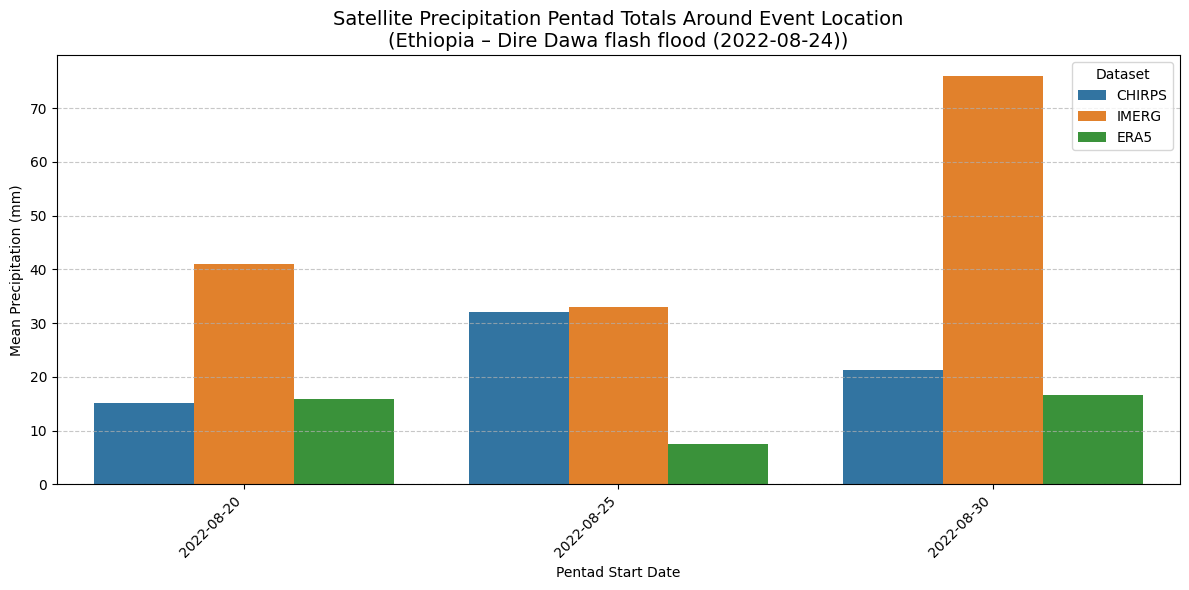

💾 Saved: ./Results_SkillExplorer_Ethiopia_2026-06-28/event_pixels_pentad_timeseries_Ethiopia.png


In [13]:
# @title 9b) Extract Satellite Precipitation Pixels Around Event Location and Plot Time Series {"display-mode":"form"}
# @markdown This cell extracts satellite precipitation data for pixels around the chosen event location
# @markdown within the specified neighborhood and generates a combined time series plot.

import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import seaborn as sns
from IPython.display import display

# ── Dynamically find the event key for the selected country ───────────────────
event_key = next((k for k in EVENTS.keys() if k.startswith(COUNTRY)), None)

if event_key is None:
    print(f'⚠️ No case study defined for {COUNTRY}. Cannot extract satellite pixels around event.')
else:
    event_lat, event_lon = EVENTS[event_key]['coords']
    print(f"📍 Event: {event_key}")
    print(f"   Coordinates: ({event_lat}, {event_lon})")

    # ── Dataset registry (using updated variable names from Step 1/6) ─────────
    src = {
        'CHIRPS': chirps_ds,
        'TAMSAT': tamsat_ds,
        'IMERG': imerg_ds,
        'ERA5': era5_ds
    }

    event_satellite_series_pentad = {}

    # ── Determine the event date range ────────────────────────────────────────
    if 'dates' in EVENTS[event_key]:
        start_evt_str, end_evt_str = EVENTS[event_key]['dates']
        origin_date = pd.to_datetime(start_evt_str, utc=True)
        start_evt = pd.to_datetime(start_evt_str).tz_localize('UTC')
        end_evt = pd.to_datetime(end_evt_str).tz_localize('UTC')
    else:
        print("⚠️ Could not determine event date range for filtering.")
        origin_date = None
        start_evt, end_evt = None, None

    # ── Extract and aggregate pixels for each dataset ─────────────────────────
    for dataset_name, ds in src.items():
        if ds is None:
            continue

        print(f"Extracting pixels for {dataset_name} around event location...")
        try:
            # Detect spatial coordinate names
            if 'lat' in ds.coords and 'lon' in ds.coords:
                lats, lons = ds['lat'].values, ds['lon'].values
                lat_dim, lon_dim = 'lat', 'lon'
            elif 'y' in ds.coords and 'x' in ds.coords:
                lats, lons = ds['y'].values, ds['x'].values
                lat_dim, lon_dim = 'y', 'x'
            else:
                print(f"  ⚠️ Could not find spatial dimensions in {dataset_name}.")
                continue

            # Find nearest grid point
            lat_idx = np.abs(lats - event_lat).argmin()
            lon_idx = np.abs(lons - event_lon).argmin()

            # Calculate slice indices for NEIGHBORHOOD x NEIGHBORHOOD area
            lat_start = max(lat_idx - NEIGHBORHOOD // 2, 0)
            lat_end = min(lat_idx + NEIGHBORHOOD // 2 + 1, len(lats))
            lon_start = max(lon_idx - NEIGHBORHOOD // 2, 0)
            lon_end = min(lon_idx + NEIGHBORHOOD // 2 + 1, len(lons))

            sub_ds = ds.isel({lat_dim: slice(lat_start, lat_end), lon_dim: slice(lon_start, lon_end)})

            # Select precipitation variable
            precip_var = next(
                (v for v in sub_ds.data_vars
                 if any(k in v.lower() for k in ['precip', 'rainfall', 'rfe'])
                 and lat_dim in sub_ds[v].dims and 'time' in sub_ds[v].dims),
                None
            )

            if precip_var is None:
                print(f"  ⚠️ Could not find a precipitation variable in {dataset_name}.")
                continue

            # Calculate mean precipitation across neighborhood pixels
            time_series_spatial_mean = sub_ds[precip_var].mean(dim=[lat_dim, lon_dim], skipna=True)

            # Convert to pandas Series and ensure UTC timezone
            ts_series = time_series_spatial_mean.to_series()
            if ts_series.index.tzinfo is None:
                ts_series = ts_series.tz_localize('UTC')
            else:
                ts_series = ts_series.tz_convert('UTC')

            # Sort index to ensure proper resampling
            ts_series = ts_series.sort_index()

            # Resample to 5-day periods (pentads) aligned to the event start date
            if origin_date is not None:
                ts_pentad = ts_series.resample('5D', origin=origin_date).sum()
                event_satellite_series_pentad[dataset_name] = ts_pentad
                print(f"  ✅ {dataset_name}: Extracted {len(ts_pentad)} pentads.")
            else:
                print(f"  ⚠️ Cannot resample {dataset_name}: Event origin date not determined.")

        except Exception as e:
            print(f"  ❌ Error extracting {dataset_name}: {e}")

    # ── Calculate and Display Total Rainfall During Event ─────────────────────
    if start_evt is not None and end_evt is not None and event_satellite_series_pentad:
        total_rainfall_data = []

        for dataset_name, series_pentad in event_satellite_series_pentad.items():
            # Filter series to the event date range
            # We use a slight buffer to ensure pentads overlapping the event window are captured
            valid_indices = series_pentad.index[
                (series_pentad.index >= start_evt - pd.Timedelta(days=4)) &
                (series_pentad.index <= end_evt + pd.Timedelta(days=4))
            ]

            if not valid_indices.empty:
                total_rainfall = series_pentad.loc[valid_indices].sum()
                total_rainfall_data.append({
                    'Dataset': dataset_name,
                    'Total Rainfall (mm)': round(total_rainfall, 2)
                })

        if total_rainfall_data:
            total_rainfall_df = pd.DataFrame(total_rainfall_data)
            print(f"\n💧 Total Rainfall During Event Window ({start_evt.date()} to {end_evt.date()}):")
            display(total_rainfall_df)

            total_rainfall_output_path = os.path.join(RESULTS_DIR, f'event_total_rainfall_{COUNTRY}.csv')
            total_rainfall_df.to_csv(total_rainfall_output_path, index=False)
            print(f"💾 Saved: {total_rainfall_output_path}")
        else:
            print("⚠️ No total rainfall data calculated for any dataset.")

    # ── Plotting ──────────────────────────────────────────────────────────────
    if event_satellite_series_pentad and start_evt is not None and end_evt is not None:
        print("\nGenerating combined pentad time series plot...")

        plot_data = []
        for dataset_name, series_pentad in event_satellite_series_pentad.items():
            # Filter to event window (with buffer for pentad alignment)
            valid_indices = series_pentad.index[
                (series_pentad.index >= start_evt - pd.Timedelta(days=4)) &
                (series_pentad.index <= end_evt + pd.Timedelta(days=4))
            ]

            series_filtered = series_pentad.loc[valid_indices].copy()

            # Convert index to timezone-naive string for clean seaborn plotting
            series_filtered.index = series_filtered.index.tz_convert(None).strftime('%Y-%m-%d')

            for date, value in series_filtered.items():
                plot_data.append({
                    'Date': date,
                    'Dataset': dataset_name,
                    'Precipitation': value
                })

        if plot_data:
            plot_df = pd.DataFrame(plot_data)
            # Sort by date
            plot_df['Date_sort'] = pd.to_datetime(plot_df['Date'])
            plot_df = plot_df.sort_values(by='Date_sort').drop(columns=['Date_sort'])

            plt.figure(figsize=(12, 6))
            sns.barplot(data=plot_df, x='Date', y='Precipitation', hue='Dataset', dodge=True)

            plt.title(f"Satellite Precipitation Pentad Totals Around Event Location\n({event_key})", fontsize=14)
            plt.xlabel('Pentad Start Date')
            plt.ylabel('Mean Precipitation (mm)')
            plt.xticks(rotation=45, ha='right')
            plt.legend(title='Dataset')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()

            plot_output_path = os.path.join(RESULTS_DIR, f'event_pixels_pentad_timeseries_{COUNTRY}.png')
            plt.savefig(plot_output_path, dpi=150, bbox_inches='tight')
            plt.show()
            print(f"💾 Saved: {plot_output_path}")
        else:
            print("⚠️ No data available within the event date range to plot.")
    else:
        print("⚠️ Cannot generate plot: Missing satellite data or event date range.")

In [14]:
# @title 9c) Pentad Rainfall Totals During Event {"display-mode":"form"}
# @markdown This cell extracts satellite precipitation data for pixels around the chosen event location
# @markdown and generates a table of the 5-day pentad totals during the event window.
# @markdown *Note: Since the datasets are pre-aggregated to pentads in Step 1, daily totals are not available.*

import pandas as pd
import os
import numpy as np
from IPython.display import display

# ── Dynamic Event Lookup ──────────────────────────────────────────────────────
event_key = next((k for k in EVENTS.keys() if k.startswith(COUNTRY)), None)

if event_key is None:
    print(f'⚠️ No case study defined for {COUNTRY}. Cannot generate rainfall table.')
else:
    # Determine the event date range and coordinates
    if event_key in EVENTS and 'dates' in EVENTS[event_key]:
        start_evt_str, end_evt_str = EVENTS[event_key]['dates']
        start_evt = pd.to_datetime(start_evt_str).tz_localize('UTC')
        end_evt = pd.to_datetime(end_evt_str).tz_localize('UTC')
        event_lat, event_lon = EVENTS[event_key]['coords']
    else:
        print("⚠️ Could not determine event date range or coordinates.")
        start_evt, end_evt = None, None
        event_lat, event_lon = None, None

    if start_evt is not None and end_evt is not None and event_lat is not None and event_lon is not None:
        pentad_rainfall_data = {}

        # ── Dataset registry (using updated variable names from Step 1/6) ─────
        src = {
            'CHIRPS': chirps_ds,
            'TAMSAT': tamsat_ds,
            'IMERG': imerg_ds,
            'ERA5': era5_ds
        }

        for dataset_name, ds in src.items():
            if ds is None:
                continue

            print(f"Extracting pentad pixels for {dataset_name} around event location...")
            try:
                # Detect spatial coordinate names
                if 'lat' in ds.coords and 'lon' in ds.coords:
                    lats, lons = ds['lat'].values, ds['lon'].values
                    lat_dim, lon_dim = 'lat', 'lon'
                elif 'y' in ds.coords and 'x' in ds.coords:
                    lats, lons = ds['y'].values, ds['x'].values
                    lat_dim, lon_dim = 'y', 'x'
                else:
                    print(f"  ⚠️ Could not find spatial dimensions in {dataset_name}.")
                    continue

                # Find nearest grid point
                lat_idx = np.abs(lats - event_lat).argmin()
                lon_idx = np.abs(lons - event_lon).argmin()

                # Calculate slice indices for NEIGHBORHOOD x NEIGHBORHOOD area
                lat_start = max(lat_idx - NEIGHBORHOOD // 2, 0)
                lat_end = min(lat_idx + NEIGHBORHOOD // 2 + 1, len(lats))
                lon_start = max(lon_idx - NEIGHBORHOOD // 2, 0)
                lon_end = min(lon_idx + NEIGHBORHOOD // 2 + 1, len(lons))

                sub_ds = ds.isel({lat_dim: slice(lat_start, lat_end), lon_dim: slice(lon_start, lon_end)})

                # Select precipitation variable
                precip_var = next(
                    (v for v in sub_ds.data_vars
                     if any(k in v.lower() for k in ['precip', 'rainfall', 'rfe'])
                     and lat_dim in sub_ds[v].dims and 'time' in sub_ds[v].dims),
                    None
                )

                if precip_var is None:
                    print(f"  ⚠️ Could not find a precipitation variable in {dataset_name}.")
                    continue

                # Calculate mean precipitation across neighborhood pixels
                # Since the dataset is ALREADY aggregated to pentads in Step 1,
                # we just take the spatial mean directly.
                time_series_pentad = sub_ds[precip_var].mean(dim=[lat_dim, lon_dim], skipna=True)

                # Convert to pandas Series and ensure UTC timezone
                ts_series = time_series_pentad.to_series()
                if ts_series.index.tzinfo is None:
                    ts_series = ts_series.tz_localize('UTC')
                else:
                    ts_series = ts_series.tz_convert('UTC')

                # Filter to the event date range
                # We use a small buffer (4 days) to ensure we catch the pentad that contains the event end date
                valid_mask = (ts_series.index >= start_evt - pd.Timedelta(days=4)) & \
                             (ts_series.index <= end_evt + pd.Timedelta(days=4))

                pentad_filtered = ts_series[valid_mask]

                if not pentad_filtered.empty:
                    pentad_rainfall_data[dataset_name] = pentad_filtered
                    print(f"  ✅ {dataset_name}: Extracted {len(pentad_filtered)} pentads.")
                else:
                    print(f"  ℹ️ No pentad data available within the event date range for {dataset_name}.")

            except Exception as e:
                print(f"  ❌ Error extracting pixels for {dataset_name}: {e}")

        # ── Build and Display Table ───────────────────────────────────────────
        if pentad_rainfall_data:
            # Combine the pentad series into a single DataFrame
            pentad_rainfall_df = pd.concat(pentad_rainfall_data, axis=1, join='outer')

            # Calculate the total rainfall for each dataset during the event window
            total_rainfall_row = pentad_rainfall_df.sum().to_frame().T
            total_rainfall_row.index = ['Total']

            # Combine data and total row
            rainfall_with_total = pd.concat([pentad_rainfall_df, total_rainfall_row])

            # Format index to string for better display
            # We use a list comprehension to handle both Timestamps and the 'Total' string safely
            rainfall_with_total.index = [
                idx.strftime('%Y-%m-%d') if hasattr(idx, 'strftime') else str(idx)
                for idx in rainfall_with_total.index
            ]

            print(f"\n💧 Pentad Rainfall Totals (mm) Around Event Location During Event Window ({event_key}):")
            print("   (Note: Datasets are pre-aggregated to 5-day pentads in Step 1)")

            # Format the table for better readability
            styled_table = rainfall_with_total.style.format('{:.2f}')
            display(styled_table)

            # Save the rainfall data with totals to a CSV file
            rainfall_output_path = os.path.join(RESULTS_DIR, f'event_pentad_rainfall_table_{COUNTRY}.csv')
            rainfall_with_total.to_csv(rainfall_output_path)
            print(f"💾 Saved: {rainfall_output_path}")

Extracting pentad pixels for CHIRPS around event location...
  ✅ CHIRPS: Extracted 4 pentads.
Extracting pentad pixels for IMERG around event location...
  ✅ IMERG: Extracted 3 pentads.
Extracting pentad pixels for ERA5 around event location...
  ✅ ERA5: Extracted 3 pentads.

💧 Pentad Rainfall Totals (mm) Around Event Location During Event Window (Ethiopia – Dire Dawa flash flood (2022-08-24)):
   (Note: Datasets are pre-aggregated to 5-day pentads in Step 1)


,CHIRPS,IMERG,ERA5
2022-08-16,8.96,nan,nan
2022-08-19,nan,38.01,16.51
2022-08-21,15.11,nan,nan
2022-08-24,nan,41.05,15.89
2022-08-26,32.03,nan,nan
2022-08-29,nan,32.96,7.52
2022-09-01,21.32,nan,nan
Total,77.42,112.02,39.92


💾 Saved: ./Results_SkillExplorer_Ethiopia_2026-06-28/event_pentad_rainfall_table_Ethiopia.csv
